# Laboratorio 7
Melisa Mendizabal - Renato Rojas 


## 0. Configuración y carga de datos

In [1]:
import sys; print(sys.version)
import gensim.downloader as api
from gensim.test.utils import datapath
print("ok")

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
ok


In [2]:
import re, string, math, time, unicodedata
from collections import Counter
from functools import lru_cache
from array import array

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
import gensim.downloader as api
from gensim.test.utils import datapath

SEED = 42
MAX_LINES = None        # None = corpus completo. Ej: 200_000 para pruebas rápidas
WINDOW = 5              # ventana de contexto (C) para skip-gram
MIN_COUNT = 5           # umbral final de frecuencia mínima
SUBSAMPLING_T = 1e-5    # umbral t de Mikolov et al. (2013)

corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
news = load_dataset("fancyzhx/ag_news")
glove = api.load("glove-wiki-gigaword-100")

# Benchmarks (se usarán en las siguientes partes)
analogias = datapath("questions-words.txt")
wordsim = datapath("wordsim353.tsv")
simlex = datapath("simlex999.txt")

print(corpus)

c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Deep\deep_Lab7\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## 1. Tamaño del corpus: artículos, líneas y tokens

En WikiText, cada fila del dataset es una línea del archivo original. Los títulos de artículo (nivel 1) tienen la forma `" = Título = "`, y las secciones usan `" = = Sección = = "`. Contamos los artículos con los encabezados de nivel 1. Los tokens "crudos" son los separados por espacios (WikiText ya viene pre-tokenizado por espacios).

In [3]:
def corpus_stats(split):
    lines = corpus[split]["text"]
    n_lines = len(lines)
    n_nonempty = 0
    n_articles = 0
    n_tokens = 0
    for l in lines:
        s = l.strip()
        if not s:
            continue
        n_nonempty += 1
        if s.startswith("= ") and s.endswith(" ="):
            # encabezado: nivel 1 si NO empieza con "= ="
            if not s.startswith("= ="):
                n_articles += 1
        n_tokens += len(s.split())
    return dict(split=split, filas_lineas=n_lines, lineas_no_vacias=n_nonempty,
                articulos=n_articles, tokens_crudos=n_tokens)

stats = pd.DataFrame([corpus_stats(s) for s in ["train", "validation", "test"]])
stats.loc["total"] = stats.sum(numeric_only=True)
stats.loc["total", "split"] = "total"
stats

,split,filas_lineas,lineas_no_vacias,articulos,tokens_crudos
0,train,1801350.0,1165029.0,29444.0,101425671.0
1,validation,3760.0,2461.0,60.0,213886.0
2,test,4358.0,2891.0,62.0,241211.0
total,total,1809468.0,1170381.0,29566.0,101880768.0


## 2. Normalización

**Decisiones y justificación**

- Minúsculas: Sí (`str.lower()`), `glove-wiki-gigaword-100` es *uncased*. Si el vocabulario propio distingue "The"/"the", habría tokens sin equivalente en GloVe y la comparación no sería justa. También reduce la dispersión de estadísticas.
- Marcadores de WikiText (`@-@`, `@,@`, `@.@`): Se revierten: Son un artefacto del dataset; GloVe sí contiene tokens como `well-known`, `1,000`, `2.5`. 
- Números: Se conservan tal cual (sin mapear dígitos a `0` ni a `<num>`)  GloVe 6B conserva los números como tokens individuales; colapsarlos en nuestro lado rompería la comparabilidad. 
- Puntuación: Se eliminan los tokens que son solo puntuación/símbolos. Para embeddings de palabras no aportan semántica léxica y dominan las frecuencias (`,` y `.` están entre los más frecuentes). Se aplica antes de definir el contexto, como en `text8`. (Es configurable.) 
- Encabezados (`= Título =`): Se descartan. No son lenguaje natural de oraciones. 
- Tokens especiales `<pad>` (id 0) y `<unk>` (id 1). Las palabras bajo `min_count` se eliminan del flujo de entrenamiento (como hace Word2Vec) pero se contabilizan en `<unk>`

Consistencia con GloVe: mismo *casing* (minúsculas), mismo tratamiento de números y guiones, y mismo criterio de tokenización por palabra. Además se reporta qué porcentaje de nuestro vocabulario existe en GloVe.

In [4]:
AT_RE = re.compile(r" @([-,.])@ ")

@lru_cache(maxsize=None)
def is_punct(tok):
    """True si el token está formado solo por signos de puntuación o símbolos."""
    return all(unicodedata.category(c)[0] in ("P", "S") for c in tok)

def preprocess_line(line, keep_punct=False):
    """Línea cruda de WikiText -> lista de tokens normalizados (o None si se descarta)."""
    s = line.strip()
    if not s:
        return None
    if s.startswith("= ") and s.endswith(" ="):      # encabezados
        return None
    s = AT_RE.sub(r"\1", s.lower())                   # minúsculas + revertir @-@, @,@, @.@
    toks = s.split()
    if not keep_punct:
        toks = [t for t in toks if not is_punct(t)]
    return toks or None

print(preprocess_line(" The well @-@ known 1 @,@ 000 @-@ page book cost 2 @.@ 5 dollars , sir . \n"))

['the', 'well-known', '1,000-page', 'book', 'cost', '2.5', 'dollars', 'sir']


## 3. Tokenizador por palabra propio vs. librería (NLTK y spaCy)

Nuestro tokenizador: una palabra es una secuencia alfanumérica que puede contener `-`, `'`, `.` o `,` *internos* (así `well-known`, `don't`, `3,500.75` quedan enteros); cualquier otro símbolo es un token aparte.

In [5]:
import spacy
from nltk.tokenize import NLTKWordTokenizer

TOKEN_RE = re.compile(r"[^\W_]+(?:[-'’.,][^\W_]+)*|\S")

def my_tokenize(text):
    return TOKEN_RE.findall(text)

nltk_tok = NLTKWordTokenizer()
nlp = spacy.blank("en")           # solo el tokenizador de spaCy (reglas), no requiere descargar modelo

def nltk_tokenize(text): return nltk_tok.tokenize(text)
def spacy_tokenize(text): return [t.text for t in nlp.make_doc(text)]

sentences = [
    "I don't think they'll finish the state-of-the-art project on time.",
    "Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.",
    "It's a well-known fact that e-mail isn't dead.",
    "The company earned $3,500.75 in Q3, up 12.5% from last year.",
    "She said: \"Let's meet at 5:30 p.m.\" and left.",
    "Visit https://www.example.com or write to john.doe@mail.com.",
    "They've been co-operating with the mother-in-law since 1990-1995.",
    "Wouldn't you rather go to New York City?",
    "The O'Neill family can't afford a 3-bedroom house.",
    "AT&T and Procter & Gamble announced a $5 billion deal.",
    "He's 6'2\" tall; it's rock 'n' roll!",
    "Cannot is one word, but gonna and wanna are informal.",
]

rows = []
for s in sentences:
    a, b, c = my_tokenize(s), nltk_tokenize(s), spacy_tokenize(s)
    rows.append({"oración": s, "n_propio": len(a), "n_nltk": len(b), "n_spacy": len(c),
                 "solo_propio_vs_nltk": sorted(set(a) - set(b)),
                 "solo_nltk_vs_propio": sorted(set(b) - set(a)),
                 "solo_spacy_vs_propio": sorted(set(c) - set(a))})
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows)

,oración,n_propio,n_nltk,n_spacy,solo_propio_vs_nltk,solo_nltk_vs_propio,solo_spacy_vs_propio
0,I don't think they'll finish the state-of-the-art project on time.,11,13,19,"[don't, they'll]","['ll, do, n't, they]","['ll, -, art, do, n't, of, state, they]"
1,Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.,18,15,15,"[Dr, Inc, U.S]","[Dr., Inc., U.S.]","[Dr., Inc., U.S.]"
2,It's a well-known fact that e-mail isn't dead.,9,11,15,"[It's, isn't]","['s, It, is, n't]","['s, -, It, e, is, known, mail, n't, well]"
3,"The company earned $3,500.75 in Q3, up 12.5% from last year.",15,15,15,[],[],[]
4,"She said: ""Let's meet at 5:30 p.m."" and left.",16,14,14,"["", 30, 5, Let's, p.m]","['', 's, 5:30, Let, ``, p.m.]","['s, 5:30, Let, p.m.]"
5,Visit https://www.example.com or write to john.doe@mail.com.,13,11,7,"[/, www.example.com]",[//www.example.com],"[https://www.example.com, john.doe@mail.com]"
6,They've been co-operating with the mother-in-law since 1990-1995.,9,10,18,[They've],"['ve, They]","['ve, -, 1990, 1995, They, co, in, law, mother, operating]"
7,Wouldn't you rather go to New York City?,9,10,10,[Wouldn't],"[Would, n't]","[Would, n't]"
8,The O'Neill family can't afford a 3-bedroom house.,9,10,12,[can't],"[ca, n't]","[-, 3, bedroom, ca, n't]"
9,AT&T and Procter & Gamble announced a $5 billion deal.,14,14,12,[],[],[AT&T]


In [6]:
for s in sentences:
    print(s)
    print("  propio:", my_tokenize(s))
    print("  nltk  :", nltk_tokenize(s))
    print("  spacy :", spacy_tokenize(s))
    print()

I don't think they'll finish the state-of-the-art project on time.
  propio: ['I', "don't", 'think', "they'll", 'finish', 'the', 'state-of-the-art', 'project', 'on', 'time', '.']
  nltk  : ['I', 'do', "n't", 'think', 'they', "'ll", 'finish', 'the', 'state-of-the-art', 'project', 'on', 'time', '.']
  spacy : ['I', 'do', "n't", 'think', 'they', "'ll", 'finish', 'the', 'state', '-', 'of', '-', 'the', '-', 'art', 'project', 'on', 'time', '.']

Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.
  propio: ['Dr', '.', 'Smith', 'moved', 'to', 'the', 'U.S', '.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc', '.', 'now', '.']
  nltk  : ['Dr.', 'Smith', 'moved', 'to', 'the', 'U.S.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc.', 'now', '.']
  spacy : ['Dr.', 'Smith', 'moved', 'to', 'the', 'U.S.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc.', 'now', '.']

It's a well-known fact that e-mail isn't dead.
  propio: ["It's", 'a', 'well-known', 'fact', 'that', 'e-mail', "

### Análisis

- **Contracciones** (`don't`, `they'll`, `isn't`, `can't`): NLTK separa `do` + `n't`, `they` + `'ll`; spaCy también las separa (`do` + `n't`); nuestro tokenizador las deja enteras. ¿Cuál conviene para embeddings? GloVe 6B usa el esquema tipo Penn Treebank (`n't` como token separado).
- **Guiones** (`state-of-the-art`, `mother-in-law`, `1990-1995`): ...
- **Abreviaturas** (`Dr.`, `U.S.`, `Inc.`, `p.m.`): ...
- **Monedas, porcentajes, URLs, emails, `AT&T`**: ...
- **Palabras compuestas por convención** (`cannot`, `gonna`, `wanna`): ...
- **Decisión para el pipeline:** como el corpus de WikiText ya viene pre-tokenizado por espacios, usamos `split()` sobre el texto normalizado (sección 2) en lugar de re-tokenizar 100M de tokens; el tokenizador propio se usa para texto libre (p. ej. AG News más adelante).

## 4. Conteo de frecuencias y ley de Zipf

Primera pasada sobre el corpus de entrenamiento (`train`) para contar palabras normalizadas.

In [7]:
def iter_clean_lines(split="train", max_lines=MAX_LINES):
    lines = corpus[split]["text"]
    if max_lines is not None:
        lines = lines[:max_lines]
    for line in tqdm(lines, desc=f"procesando {split}"):
        toks = preprocess_line(line)
        if toks:
            yield toks

t0 = time.time()
counts = Counter()
for toks in iter_clean_lines("train"):
    counts.update(toks)
TOTAL_TOKENS = sum(counts.values())
print(f"Tokens normalizados: {TOTAL_TOKENS:,} | tipos (palabras distintas): {len(counts):,} | {time.time()-t0:.0f}s")
print(counts.most_common(15))

procesando train: 100%|██████████| 1801350/1801350 [00:47<00:00, 37609.28it/s]

Tokens normalizados: 84,585,500 | tipos (palabras distintas): 734,347 | 48s
[('the', 6421976), ('of', 2725438), ('and', 2461131), ('in', 2160170), ('to', 1985700), ('a', 1766349), ('was', 1076072), ('on', 762213), ("'s", 725138), ('as', 724218), ('for', 697864), ('that', 691051), ('with', 649207), ('by', 628144), ('is', 516512)]


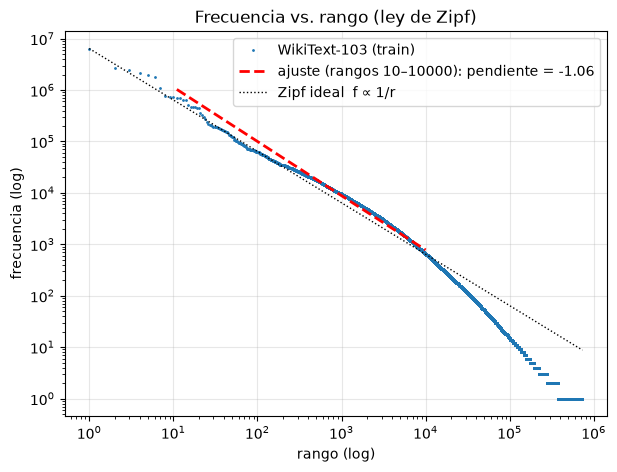

,top-k,% de tokens cubiertos
0,10,24.600440
1,1000,63.909665
2,30000,94.589613


In [8]:
freqs = np.array(sorted(counts.values(), reverse=True), dtype=np.int64)
ranks = np.arange(1, len(freqs) + 1)

# Ajuste lineal en log-log en el tramo "central" (evita la cabeza y la larga cola de hapax)
lo, hi = 10, 10_000
slope, intercept = np.polyfit(np.log10(ranks[lo:hi]), np.log10(freqs[lo:hi]), 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, freqs, ".", ms=2, label="WikiText-103 (train)")
ax.loglog(ranks[lo:hi], 10**intercept * ranks[lo:hi]**slope, "r--", lw=2,
          label=f"ajuste (rangos {lo}–{hi}): pendiente = {slope:.2f}")
ax.loglog(ranks, freqs[0] / ranks, "k:", lw=1, label="Zipf ideal  f ∝ 1/r")
ax.set_xlabel("rango (log)"); ax.set_ylabel("frecuencia (log)")
ax.set_title("Frecuencia vs. rango (ley de Zipf)"); ax.legend(); ax.grid(alpha=.3)
plt.show()

cum = np.cumsum(freqs) / freqs.sum()
cobertura = pd.DataFrame({"top-k": [10, 1_000, 30_000],
                          "% de tokens cubiertos": [100 * cum[k - 1] for k in (10, 1_000, 30_000)]})
cobertura

La relación es aproximadamente lineal en log-log en el tramo central. El ajuste entre los rangos 10 y 10,000 da una pendiente de −1.06, es decir `f(r) ∝ 1/r^α` con α ≈ 1.06, muy cerca del α = 1 de la ley de Zipf clásica. Por tanto, sí se cumple la ley de Zipf de forma aproximada.

Se observan desviaciones en los extremos:
- **Cabeza (rangos ≲ 10):** las palabras más frecuentes quedan algo por encima de la recta ideal 1/r. Las funcionales más comunes aparecen más veces de lo que predice Zipf.
- **Cola (rangos ≳ 10⁴):** la curva cae por debajo de la recta ideal y termina en una "escalera" con frecuencias de 1, 2, 3, …. Esto ocurre porque las frecuencias son enteras y hay una enorme cantidad de palabras con muy pocas apariciones (nombres propios, cifras, términos técnicos, errores). En un corpus finito, la cola no puede seguir la ley de potencias indefinidamente.

**Cobertura del corpus:**

| Top-k palabras | % de tokens cubiertos |
|---|---|
| 10 | 24.6 % |
| 1,000 | 63.9 % |
| 30,000 | 94.6 % |

Las 10 palabras más frecuentes, casi todas funcionales (*the*, *of*, *and*, …), cubren por sí solas cerca de una cuarta parte del texto. Con solo 1,000 palabras se cubre casi dos tercios, y con 30,000 (una fracción muy pequeña del total de tipos, que son cientos de miles) ya se cubre el 94.6 %. El 5.4 % restante está repartido en la cola larga, que concentra la gran mayoría de los tipos distintos.

**Consecuencias para el entrenamiento:**
1. Unas pocas palabras dominan los pares (central, contexto). Esto aporta poca información y encarece cada epoch, lo que justifica el submuestreo de palabras frecuentes.
2. La mayoría de los tipos aparece muy pocas veces, por lo que sus vectores serían ruidosos y de baja calidad. Además, inflarían el vocabulario y los parámetros del modelo, lo que justifica un umbral de `min_count`. Con 94.6 % de cobertura a 30,000 palabras, se puede recortar mucho el vocabulario perdiendo muy pocos tokens.

## 5. Vocabulario con frecuencia mínima (`min_count`)

In [9]:
def vocab_stats(min_count):
    kept = {w: c for w, c in counts.items() if c >= min_count}
    covered = sum(kept.values())
    in_glove = sum(1 for w in kept if w in glove.key_to_index)
    return {"min_count": min_count,
            "tamaño vocab": len(kept) + 2,                      # +<pad>, <unk>
            "% tokens <unk>": 100 * (1 - covered / TOTAL_TOKENS),
            "% tipos descartados": 100 * (1 - len(kept) / len(counts)),
            "% vocab que está en GloVe": 100 * in_glove / len(kept)}

pd.DataFrame([vocab_stats(m) for m in (1, 3, 5, 10, 20, 50, 100)]).round(2)

,min_count,tamaño vocab,% tokens <unk>,% tipos descartados,% vocab que está en GloVe
0,1,734349,0.00,0.00,36.42
1,3,274723,0.66,62.59,70.85
2,5,195028,0.98,73.44,81.72
3,10,128305,1.50,82.53,90.96
4,20,86325,2.17,88.24,95.81
5,50,51407,3.46,93.00,99.06
6,100,33828,4.91,95.39,99.66


**Respuesta:** al subir `min_count` el vocabulario se reduce drásticamente (se pierden muchísimos tipos raros) pero el porcentaje de tokens desconocidos crece muy poco, porque esos tipos suman pocas apariciones. Para este trabajo usaremos `MIN_COUNT = 5` (el valor por defecto de gensim): un buen compromiso entre tamaño del modelo y calidad de los vectores. Justifica aquí tu elección con la tabla.

### Construcción final del vocabulario y conversión a IDs

In [10]:
PAD, UNK = "<pad>", "<unk>"
words = [w for w, c in counts.most_common() if c >= MIN_COUNT]
itos = [PAD, UNK] + words
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)

cnt = np.zeros(V, dtype=np.int64)
cnt[2:] = [counts[w] for w in words]
cnt[1] = TOTAL_TOKENS - cnt.sum()          # tokens desconocidos (<unk>)
print(f"|V| = {V:,} | % <unk> = {100*cnt[1]/TOTAL_TOKENS:.2f}%")

# Segunda pasada: texto -> IDs. Los <unk> se eliminan del flujo (como Word2Vec).
ids_buf = array("i")
line_lens = []
for toks in iter_clean_lines("train"):
    row = [stoi[t] for t in toks if t in stoi]
    if row:
        ids_buf.extend(row)
        line_lens.append(len(row))

ids = np.frombuffer(ids_buf, dtype=np.int32)
line_lens = np.array(line_lens, dtype=np.int64)
N = ids.size
print(f"Tokens en el flujo de entrenamiento: {N:,} | secuencias (párrafos): {len(line_lens):,}")
print("Ejemplo:", [itos[i] for i in ids[:15]])

|V| = 195,028 | % <unk> = 0.98%


procesando train: 100%|██████████| 1801350/1801350 [00:50<00:00, 35907.07it/s]

Tokens en el flujo de entrenamiento: 83,753,871 | secuencias (párrafos): 859,099
Ejemplo: ['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred']


## 6. Submuestreo (subsampling) de palabras frecuentes


In [11]:
def keep_prob(cnt, N, t, variant="paper"):
    f = np.maximum(cnt / N, 1e-12)
    if variant == "paper":
        p = np.sqrt(t / f)
    else:                                  # versión del código C
        p = (np.sqrt(f / t) + 1) * t / f
    return np.clip(p, 0.0, 1.0)

rows = []
for t in (1e-3, 1e-4, 1e-5):
    for variant in ("paper", "word2vec-C"):
        kp = keep_prob(cnt, N, t, "paper" if variant == "paper" else "c")
        r = {"t": t, "fórmula": variant}
        for w in ("the", "of", "and"):
            r[f"% descartado '{w}'"] = 100 * (1 - kp[stoi[w]])
        # fracción esperada del corpus que se conserva
        r["% corpus conservado"] = 100 * (kp[ids].mean() if N < 5e7 else (kp * (cnt / N)).sum())
        rows.append(r)
pd.DataFrame(rows).round(2)

,t,fórmula,% descartado 'the',% descartado 'of',% descartado 'and',% corpus conservado
0,0.0,paper,88.58,82.47,81.55,73.70
1,0.0,word2vec-C,87.28,79.40,78.15,77.96
2,0.0,paper,96.39,94.46,94.17,54.25
3,0.0,word2vec-C,96.26,94.15,93.83,60.49
4,0.0,paper,98.86,98.25,98.16,30.71
5,0.0,word2vec-C,98.84,98.22,98.12,36.34


In [12]:
# Realización estocástica (lo que ocurriría en una epoch) con t = SUBSAMPLING_T
rng = np.random.default_rng(SEED)
kp = keep_prob(cnt, N, SUBSAMPLING_T, "paper")
mask = rng.random(N, dtype=np.float32) < kp[ids]

for w in ("the", "of", "and"):
    sel = ids == stoi[w]
    print(f"'{w}': f = {cnt[stoi[w]]/N:.4f} | descartado teórico = {100*(1-kp[stoi[w]]):.2f}% "
          f"| descartado empírico = {100*(1-mask[sel].mean()):.2f}%")
print(f"Tokens: {N:,} -> {mask.sum():,}  ({100*mask.mean():.1f}% conservado)")

'the': f = 0.0767 | descartado teórico = 98.86% | descartado empírico = 98.86%
'of': f = 0.0325 | descartado teórico = 98.25% | descartado empírico = 98.25%
'and': f = 0.0294 | descartado teórico = 98.16% | descartado empírico = 98.15%
Tokens: 83,753,871 -> 25,698,179  (30.7% conservado)


**¿Por qué ayuda al entrenamiento?**

1. **Eficiencia:** las palabras funcionales (`the`, `of`, `and`) suman una fracción enorme de los tokens y generan millones de pares (central, contexto) muy poco informativos; descartarlas reduce el cómputo por epoch.
2. **Calidad:** `(the, París)` aporta muy poca información sobre `París`, porque `the` coocurre con casi todo; los vectores de palabras frecuentes ya se estabilizan tras pocos ejemplos, así que ver millones más es redundante.
3. **Más peso para palabras raras e informativas:** al quitar parte de las frecuentes, las ventanas se "comprimen" y las palabras de contenido quedan más cerca (contextos efectivos más amplios y más informativos), lo que mejora las representaciones de palabras de frecuencia media y baja.
4. Mikolov et al. reportan aceleraciones de 2×–10× y mejor precisión en analogías.

## 7. Pares (palabra central, contexto) para skip-gram


In [13]:
def n_pairs(lengths, C):
    L = np.asarray(lengths, dtype=np.int64)
    d = np.minimum(C, L - 1)
    return int((2 * (d * L - d * (d + 1) // 2)).sum())

def skipgram_pairs(seq, C):
    """Generador explícito de pares (central, contexto) de una secuencia de IDs."""
    n = len(seq)
    for i in range(n):
        for j in range(max(0, i - C), min(n, i + C + 1)):
            if j != i:
                yield seq[i], seq[j]

# Demo con una oración
demo = [stoi[w] for w in "the quick brown fox jumps over the lazy dog".split() if w in stoi]
print([(itos[a], itos[b]) for a, b in skipgram_pairs(demo, 2)][:12], "...")

# Verificación: fórmula cerrada vs. generador en las primeras 2,000 secuencias
offs = np.concatenate([[0], np.cumsum(line_lens)])
check = sum(sum(1 for _ in skipgram_pairs(ids[offs[k]:offs[k+1]].tolist(), WINDOW)) for k in range(2000))
assert check == n_pairs(line_lens[:2000], WINDOW), "la fórmula no coincide con el generador"
print("Verificación OK:", check, "pares en 2,000 secuencias")

[('the', 'quick'), ('the', 'brown'), ('quick', 'the'), ('quick', 'brown'), ('quick', 'fox'), ('brown', 'the'), ('brown', 'quick'), ('brown', 'fox'), ('brown', 'jumps'), ('fox', 'quick'), ('fox', 'brown'), ('fox', 'jumps')] ...
Verificación OK: 1917496 pares en 2,000 secuencias


In [14]:
pairs_before = n_pairs(line_lens, WINDOW)

line_of = np.repeat(np.arange(len(line_lens), dtype=np.int32), line_lens)
new_lens = np.bincount(line_of[mask], minlength=len(line_lens))
pairs_after = n_pairs(new_lens, WINDOW)
del line_of

resumen = pd.DataFrame({
    "": ["sin submuestreo", f"con submuestreo (t={SUBSAMPLING_T:g})"],
    "tokens": [N, int(mask.sum())],
    f"pares por epoch (C={WINDOW})": [pairs_before, pairs_after],
})
resumen["reducción de pares"] = ["—", f"{100*(1 - pairs_after/pairs_before):.1f}%"]
resumen

,,tokens,pares por epoch (C=5),reducción de pares
0,sin submuestreo,83753871,812165972,—
1,con submuestreo (t=1e-05),25698179,232429016,71.4%


In [15]:
# Sensibilidad al umbral t (una realización por valor)
rows = []
for t in (1e-3, 1e-4, 1e-5):
    kp_t = keep_prob(cnt, N, t, "paper")
    m = np.random.default_rng(SEED).random(N, dtype=np.float32) < kp_t[ids]
    lo_ = np.repeat(np.arange(len(line_lens), dtype=np.int32), line_lens)
    nl = np.bincount(lo_[m], minlength=len(line_lens)); del lo_
    rows.append({"t": t, "tokens conservados": int(m.sum()), f"pares/epoch (C={WINDOW})": n_pairs(nl, WINDOW)})
pd.DataFrame(rows)

,t,tokens conservados,pares/epoch (C=5)
0,0.00100,61461782,589292214
1,0.00010,45350615,428331958
2,0.00001,25698179,232429016


**Notas**

- El submuestreo se aplica de forma aleatoria en cada epoch, por lo que el número exacto de pares varía ligeramente entre epochs; aquí reportamos una realización (la esperanza es casi idéntica por el tamaño del corpus).
- Si se usa ventana dinámica como en Word2Vec (tamaño efectivo muestreado uniformemente en `[1, C]`), el número esperado de pares es aproximadamente el que resulta de una ventana de `(C+1)/2`.
- Cada par positivo se acompaña de `k` negativos en negative sampling, así que el costo real por epoch es ≈ `(1 + k) ×` el número de pares.
- Al eliminar tokens frecuentes *antes* de abrir la ventana, el contexto efectivo se extiende más allá de `C` palabras originales.

# Inciso 4. Construcción y entrenamiento de los embeddings

**Diseño del experimento**

- **Corpus:** el flujo de IDs de la sección 2 (`ids`, sin `<unk>`, sin encabezados, sin puntuación). Las fracciones del corpus (25 %, 50 %, 100 %) son prefijos en secuencias completas; el 25 % ya supera el mínimo de 20 M tokens.
- **Mismo vocabulario para SGNS y gensim:** se usa el vocabulario de la sección 2 (`min_count = 5`); las frecuencias para submuestreo y para la distribución de negativos se recalculan sobre la fracción usada. Ambos modelos ven exactamente el mismo archivo/flujo de tokens.
- **Submuestreo:** para que SGNS sea equivalente a gensim se usa la fórmula del código C de Word2Vec (la que implementa gensim con `sample=t`), aplicada de nuevo en cada epoch antes de abrir la ventana.
- **Ventana dinámica:** como Word2Vec, para cada palabra central se muestrea `b ~ U{1..C}` y solo se usan contextos a distancia ≤ b.
- **Negativos:** `k` negativos por par, muestreados de la distribución unigrama^0.75 mediante una tabla precalculada en GPU.
- **Optimización:** dos tablas `nn.Embedding(sparse=True)` (W de entrada, W' de salida) con `SparseAdam` y learning rate con decaimiento lineal. W se inicializa en U(−0.5/d, 0.5/d) y W' en ceros, como en Word2Vec. Se conserva W.
- **Selección de configuraciones:** solo con WordSim-353 y `questions-words.txt` (SimLex-999 se reserva para la sección 6). Las analogías por epoch se evalúan con `evaluate_word_analogies` de gensim restringido a las 30,000 palabras más frecuentes de cada modelo.
- **Caché:** cada modelo entrenado se guarda en `modelos/` (vectores `.kv` + historial `.json`). Si el archivo existe, se carga en lugar de reentrenar. Para forzar reentrenamiento: `FORCE_RETRAIN = True` o borrar el archivo.

In [16]:
import os, json, gc, platform, multiprocessing
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import KeyedVectors, Word2Vec
from gensim.models.word2vec import LineSentence

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "sin GPU"
CPU_NAME = f"{platform.processor()} ({multiprocessing.cpu_count()} hilos)"
print("Dispositivo:", DEVICE, "|", GPU_NAME, "|", CPU_NAME)

MODELS_DIR = "modelos"
os.makedirs(MODELS_DIR, exist_ok=True)
FORCE_RETRAIN = False                     # True = ignorar la caché y reentrenar todo

CONTROL_WORDS = ["king", "france", "computer", "good", "january", "run"]
ANALOGY_RESTRICT = 30_000

def save_json(obj, path):
    def conv(o):
        if hasattr(o, "item"):
            return o.item()
        if isinstance(o, np.ndarray):
            return o.tolist()
        return str(o)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(obj, fh, ensure_ascii=False, indent=1, default=conv)

def load_json(path):
    with open(path, encoding="utf-8") as fh:
        return json.load(fh)

# Liberar memoria RAM de objetos de la sección 2 que ya no se necesitan
for _v in ("mask", "kp", "resumen", "new_lens", "counts", "ids_buf"):
    globals().pop(_v, None)
_ = gc.collect()

pd.set_option("display.max_columns", None)       # mostrar todas las columnas de las tablas
pd.set_option("display.width", 250)
# 20 colores distintos (primero los 10 intensos de tab20, luego los 10 claros) para que no se repitan en las gráficas
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[plt.cm.tab20(k) for k in list(range(0, 20, 2)) + list(range(1, 20, 2))])

Dispositivo: cuda | NVIDIA GeForce RTX 4060 Laptop GPU | Intel64 Family 6 Model 191 Stepping 2, GenuineIntel (24 hilos)


In [17]:
# ---------- Subconjuntos del corpus ----------
OFFS = np.concatenate([[0], np.cumsum(line_lens)]).astype(np.int64)   # inicio de cada secuencia en `ids`

def corpus_subset(frac):
    """Prefijo del corpus, en secuencias completas, con ~frac de los tokens. Devuelve (n_secuencias, n_tokens)."""
    if frac >= 1:
        n_lines = len(line_lens)
    else:
        n_lines = int(np.searchsorted(OFFS, frac * N, side="left"))
    return n_lines, int(OFFS[n_lines])

for f in (0.25, 0.5, 1.0):
    nl, nt = corpus_subset(f)
    print(f"fracción {f:>4}: {nl:,} secuencias | {nt:,} tokens")

fracción 0.25: 216,043 secuencias | 20,938,562 tokens
fracción  0.5: 429,545 secuencias | 41,877,000 tokens
fracción  1.0: 859,099 secuencias | 83,753,871 tokens


In [ ]:
#  Evaluación (WordSim-353, analogías, vecinos) 
def kv_from_matrix(W, cnt_vec):
    """KeyedVectors con las palabras que aparecen en el corpus usado, ordenadas por frecuencia (desc)."""
    order = np.argsort(-cnt_vec, kind="stable")
    order = order[cnt_vec[order] > 0]
    kv = KeyedVectors(W.shape[1])
    kv.add_vectors([itos[i] for i in order], W[order])
    return kv

def eval_analogies_gensim(kv, restrict=ANALOGY_RESTRICT):
    total, sections = kv.evaluate_word_analogies(analogias, restrict_vocab=restrict)
    sc = sn = yc = yn = 0
    for s in sections:
        if s["section"] == "Total accuracy":
            continue
        c, n = len(s["correct"]), len(s["correct"]) + len(s["incorrect"])
        if s["section"].startswith("gram"):
            yc += c; yn += n
        else:
            sc += c; sn += n
    return {"sem": sc / max(sn, 1), "syn": yc / max(yn, 1), "total": float(total)}

def spearman_pairs(kv, path):
    pearson, spearman, oov = kv.evaluate_word_pairs(path)
    return float(spearman[0]), float(oov)

def evaluate_kv(kv):
    m = eval_analogies_gensim(kv)
    m["ws353"], m["ws353_oov"] = spearman_pairs(kv, wordsim)
    m["vecinos"] = {w: ([(x, round(float(s), 3)) for x, s in kv.most_similar(w, topn=5)]
                        if w in kv.key_to_index else []) for w in CONTROL_WORDS}
    return m

def print_metrics(prefix, m):
    print(f"{prefix} | analogías sem {m['sem']:.3f} sin {m['syn']:.3f} total {m['total']:.3f} | WS353 ρ {m['ws353']:.3f}")
    print("    vecinos:", {w: [x for x, _ in v] for w, v in m["vecinos"].items()})

# Referencia: GloVe evaluado con exactamente el mismo protocolo
_gpath = os.path.join(MODELS_DIR, "glove_eval.json")
if os.path.exists(_gpath) and not FORCE_RETRAIN:
    GLOVE_EVAL = load_json(_gpath)
else:
    GLOVE_EVAL = evaluate_kv(glove)
    save_json(GLOVE_EVAL, _gpath)
print_metrics("GloVe-100", GLOVE_EVAL)

GloVe-100 | analogías sem 0.655 sin 0.655 total 0.655 | WS353 ρ 0.533
    vecinos: {'king': ['prince', 'queen', 'son', 'brother', 'monarch'], 'france': ['belgium', 'french', 'britain', 'spain', 'paris'], 'computer': ['computers', 'software', 'technology', 'pc', 'hardware'], 'good': ['better', 'sure', 'really', 'kind', 'very'], 'january': ['december', 'october', 'february', 'november', 'september'], 'run': ['running', 'runs', 'ran', 'out', 'go']}


### 4.1 Skip-gram con negative sampling (SGNS) desde cero en PyTorch


In [19]:
class SGNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.inp = nn.Embedding(vocab_size, dim, sparse=True)   # W  : palabra central
        self.out = nn.Embedding(vocab_size, dim, sparse=True)   # W' : palabra de contexto
        nn.init.uniform_(self.inp.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.out.weight)

    def forward(self, center, context, negatives):
        v = self.inp(center)                                    # (B, d)
        u_pos = self.out(context)                               # (B, d)
        u_neg = self.out(negatives)                             # (B, k, d)
        pos = F.logsigmoid((v * u_pos).sum(-1))
        neg = F.logsigmoid(-torch.bmm(u_neg, v.unsqueeze(-1)).squeeze(-1)).sum(-1)
        return -(pos + neg).mean()


def build_neg_table(cnt_vec, size=10_000_000, power=0.75):
    """Tabla unigrama^0.75 (como Word2Vec): muestrear negativos = indexar posiciones aleatorias."""
    p = cnt_vec.astype(np.float64) ** power
    p /= p.sum()
    table = np.repeat(np.arange(len(p), dtype=np.int64), np.round(p * size).astype(np.int64))
    return torch.from_numpy(table).to(DEVICE)


def iter_pair_batches(n_tok, keep_p, C, batch_size, gen, rng, chunk_tokens=4_000_000):
    """Genera lotes (central, contexto) de una epoch: submuestreo + ventana dinámica, por bloques en GPU."""
    starts = np.arange(0, n_tok, chunk_tokens)
    order = rng.permutation(len(starts))
    for k, s in enumerate(starts[order]):
        e = min(s + chunk_tokens, n_tok)
        tok = torch.from_numpy(ids[s:e].astype(np.int64)).to(DEVICE)
        line = torch.from_numpy(np.searchsorted(OFFS, np.arange(s, e), side="right") - 1).to(DEVICE)
        keep = torch.rand(tok.numel(), device=DEVICE, generator=gen) < keep_p[tok]     # submuestreo
        tok, line = tok[keep], line[keep]
        M = tok.numel()
        if M < 2:
            continue
        b = torch.randint(1, C + 1, (M,), device=DEVICE, generator=gen)               # ventana dinámica
        cs, xs = [], []
        for d in range(1, min(C, M - 1) + 1):
            same = line[:-d] == line[d:]                     # no cruzar fronteras de párrafo
            m1 = same & (b[:-d] >= d)                        # central i, contexto i+d
            cs.append(tok[:-d][m1]); xs.append(tok[d:][m1])
            m2 = same & (b[d:] >= d)                         # central i+d, contexto i
            cs.append(tok[d:][m2]); xs.append(tok[:-d][m2])
        c, x = torch.cat(cs), torch.cat(xs)
        perm = torch.randperm(c.numel(), device=DEVICE, generator=gen)
        c, x = c[perm], x[perm]
        nb = math.ceil(c.numel() / batch_size)
        for i in range(nb):
            yield k, len(starts), i, nb, c[i * batch_size:(i + 1) * batch_size], x[i * batch_size:(i + 1) * batch_size]
        del tok, line, keep, b, cs, xs, c, x


def sgns_paths(name):
    return os.path.join(MODELS_DIR, f"sgns_{name}.kv"), os.path.join(MODELS_DIR, f"sgns_{name}.json")


def train_sgns(cfg, log_every=2000):
    name = cfg["name"]
    kv_path, hist_path = sgns_paths(name)
    if not FORCE_RETRAIN and os.path.exists(kv_path) and os.path.exists(hist_path):
        print(f"[caché] {name}: modelo ya entrenado, se carga el historial")
        return load_json(hist_path)

    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    gen = torch.Generator(device=DEVICE); gen.manual_seed(SEED)

    n_lines, n_tok = corpus_subset(cfg["frac"])
    cnt_sub = np.bincount(ids[:n_tok], minlength=V).astype(np.int64)
    valid = cnt_sub >= cfg["min_count"]
    cnt_valid = np.where(valid, cnt_sub, 0)
    N_eff = int(cnt_valid.sum())
    keep_p = torch.tensor(keep_prob(cnt_valid, N_eff, cfg["t"], "c") * valid, dtype=torch.float32, device=DEVICE)
    neg_table = build_neg_table(cnt_valid)

    model = SGNS(V, cfg["dim"]).to(DEVICE)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=cfg["lr"])
    E = cfg["epochs"]
    hist = {"config": cfg, "tokens_corpus": n_tok, "tokens_vocab": N_eff, "vocab_size": int(valid.sum()),
            "epochs": [], "loss_steps": []}
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    print(f"=== SGNS {name}: {cfg} | tokens {n_tok:,} | |V| {int(valid.sum()):,}")
    t_total, step = time.time(), 0
    win_loss, win_n = torch.zeros((), device=DEVICE), 0
    for ep in range(E):
        model.train()
        t0 = time.time()
        ep_loss, ep_pairs = torch.zeros((), device=DEVICE), 0
        for k, nk, i, nb, c, x in iter_pair_batches(n_tok, keep_p, cfg["window"], cfg["batch"], gen, rng):
            progress = (ep + (k + i / nb) / nk) / E
            for g in opt.param_groups:
                g["lr"] = cfg["lr"] * max(1e-4, 1.0 - progress)
            neg = neg_table[torch.randint(0, neg_table.numel(), (c.numel(), cfg["neg"]), device=DEVICE, generator=gen)]
            loss = model(c, x, neg)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            ep_loss += loss.detach() * c.numel(); ep_pairs += c.numel()
            win_loss += loss.detach(); win_n += 1; step += 1
            if step % log_every == 0:
                hist["loss_steps"].append((step, float(win_loss / win_n)))
                win_loss.zero_(); win_n = 0
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t_ep = time.time() - t0
        gpu_mb = torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == "cuda" else 0.0

        kv = kv_from_matrix(model.inp.weight.detach().cpu().numpy(), cnt_valid)
        m = evaluate_kv(kv)
        rec = {"epoch": ep + 1, "loss": float(ep_loss / max(ep_pairs, 1)), "pares": int(ep_pairs),
               "tiempo_s": t_ep, "gpu_pico_mb": gpu_mb, **m}
        hist["epochs"].append(rec)
        print(f"[{name}] epoch {ep+1}/{E} | loss {rec['loss']:.4f} | pares {ep_pairs:,} | {t_ep:.0f}s | GPU pico {gpu_mb:.0f} MB")
        print_metrics("   ", m)
        if ep < E - 1:
            del kv
            gc.collect()

    hist["tiempo_entrenamiento_s"] = sum(e["tiempo_s"] for e in hist["epochs"])
    hist["tiempo_total_s"] = time.time() - t_total            # incluye las evaluaciones por epoch
    hist["gpu_pico_mb"] = max(e["gpu_pico_mb"] for e in hist["epochs"])
    hist["hardware"] = GPU_NAME
    kv.save(kv_path)
    save_json(hist, hist_path)

    del model, opt, neg_table, keep_p, kv
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return hist

### 4.2 Iteraciones

Configuración base: `d=100, C=5, k=5, t=1e-5, min_count=5, lr=2e-3 (SparseAdam), 3 epochs, 100 % del corpus`. Cada iteración cambia un hiperparámetro respecto a la base. Las marcadas como *obligatorias* cubren lo que pide el enunciado (dimensión y tamaño de corpus); el resto son opcionales y se pueden comentar si falta tiempo. Gracias a la caché, si el kernel se reinicia, las iteraciones ya terminadas no se repiten.

In [20]:
BASE = dict(dim=100, window=5, neg=5, t=1e-5, min_count=MIN_COUNT, lr=2e-3, epochs=3, frac=1.0, batch=4096)

def make_cfg(name, **kw):
    c = dict(BASE); c.update(kw); c["name"] = name
    return c

CONFIGS = [
    make_cfg("base"),                      # obligatoria (d=100, comparable con GloVe)
    make_cfg("d50", dim=50),               # obligatoria: dimensión
    make_cfg("d300", dim=300),             # obligatoria: dimensión
    make_cfg("corpus25", frac=0.25),       # obligatoria: tamaño de corpus
    make_cfg("corpus50", frac=0.50),       # obligatoria: tamaño de corpus
    make_cfg("win2", window=2),            # opcional: ventana
    make_cfg("win10", window=10),          # opcional: ventana
    make_cfg("neg15", neg=15),             # opcional: negativos
    make_cfg("t1e-4", t=1e-4),             # opcional: submuestreo
    make_cfg("mc20", min_count=20),        # opcional: min_count
    make_cfg("lr5e-3", lr=5e-3),           # opcional: learning rate
    make_cfg("ep5", epochs=5),             # opcional: epochs
]

HIST = {}
for cfg in CONFIGS:
    HIST[cfg["name"]] = train_sgns(cfg)

[caché] base: modelo ya entrenado, se carga el historial
[caché] d50: modelo ya entrenado, se carga el historial
[caché] d300: modelo ya entrenado, se carga el historial
[caché] corpus25: modelo ya entrenado, se carga el historial
[caché] corpus50: modelo ya entrenado, se carga el historial
[caché] win2: modelo ya entrenado, se carga el historial
[caché] win10: modelo ya entrenado, se carga el historial
[caché] neg15: modelo ya entrenado, se carga el historial
[caché] t1e-4: modelo ya entrenado, se carga el historial
[caché] mc20: modelo ya entrenado, se carga el historial
[caché] lr5e-3: modelo ya entrenado, se carga el historial
[caché] ep5: modelo ya entrenado, se carga el historial


In [21]:
def resumen_iter(h):
    c, last = h["config"], h["epochs"][-1]
    return {"iteración": c["name"], "dim": c["dim"], "ventana": c["window"], "negativos": c["neg"], "t": f"{c['t']:g}",
            "min_count": c["min_count"], "lr": f"{c['lr']:g}", "epochs": c["epochs"], "tokens corpus": h["tokens_corpus"],
            "|V|": h["vocab_size"], "loss final": last["loss"], "pares/epoch": last["pares"],
            "analog. sem": last["sem"], "analog. sin": last["syn"], "analog. total": last["total"],
            "WS353 ρ": last["ws353"], "t/epoch (s)": np.mean([e["tiempo_s"] for e in h["epochs"]]),
            "t entren. (min)": h["tiempo_entrenamiento_s"] / 60, "t total (min)": h["tiempo_total_s"] / 60,
            "GPU pico (MB)": h["gpu_pico_mb"]}

tabla_iter = pd.DataFrame([resumen_iter(h) for h in HIST.values()])
tabla_iter["criterio selección"] = tabla_iter["analog. total"] + tabla_iter["WS353 ρ"]

# Mejor configuración: máximo de (accuracy total de analogías + ρ WS353).
# Se restringe al corpus completo (el tamaño del corpus es un experimento, no un hiperparámetro a elegir)
# y a d=100 para compararla directamente con GloVe-100 y usarla en AG News (None = cualquier dim).
SELECT_DIM = 100
_cands = tabla_iter[tabla_iter["tokens corpus"] == tabla_iter["tokens corpus"].max()]
if SELECT_DIM is not None:
    _cands = _cands[_cands["dim"] == SELECT_DIM]
BEST_NAME = _cands.sort_values("criterio selección", ascending=False).iloc[0]["iteración"]
BEST_CFG = HIST[BEST_NAME]["config"]
print("Mejor configuración SGNS:", BEST_NAME, BEST_CFG)
tabla_iter.round(4)

Mejor configuración SGNS: t1e-4 {'dim': 100, 'window': 5, 'neg': 5, 't': 0.0001, 'min_count': 5, 'lr': 0.002, 'epochs': 3, 'frac': 1.0, 'batch': 4096, 'name': 't1e-4'}


,iteración,dim,ventana,negativos,t,min_count,lr,epochs,tokens corpus,|V|,loss final,pares/epoch,analog. sem,analog. sin,analog. total,WS353 ρ,t/epoch (s),t entren. (min),t total (min),GPU pico (MB),criterio selección
0,base,100,5,5,1e-05,5,0.002,3,83753871,195026,2.1094,170783845,0.3517,0.4801,0.4388,0.6719,124.3455,6.2173,6.4519,1410.0410,1.1107
1,d50,50,5,5,1e-05,5,0.002,3,83753871,195026,2.1575,170783845,0.2227,0.3574,0.3141,0.6370,144.9717,7.2486,7.5106,1181.1328,0.9510
2,d300,300,5,5,1e-05,5,0.002,3,83753871,195026,2.0417,170783845,0.4976,0.5557,0.5370,0.6975,205.5054,10.2753,11.1362,2326.4487,1.2345
3,corpus25,100,5,5,1e-05,5,0.002,3,20938562,90527,2.1826,41635019,0.1509,0.2425,0.2144,0.6067,35.8639,1.7932,2.0264,1382.6606,0.8211
4,corpus50,100,5,5,1e-05,5,0.002,3,41877000,132826,2.1417,84510616,0.2540,0.3803,0.3409,0.6565,56.3988,2.8199,3.0475,1401.5830,0.9974
5,win2,100,2,5,1e-05,5,0.002,3,83753871,195026,2.0713,87832100,0.2917,0.4581,0.4046,0.6489,66.2992,3.3150,3.5743,1012.9771,1.0535
6,win10,100,10,5,1e-05,5,0.002,3,83753871,195026,2.1309,298791993,0.3614,0.4670,0.4330,0.6667,205.0513,10.2526,10.4888,2024.6846,1.0997
7,neg15,100,5,15,1e-05,5,0.002,3,83753871,195026,3.0032,170783845,0.4186,0.4902,0.4672,0.6520,159.6611,7.9831,8.2912,1423.8281,1.1192
8,t1e-4,100,5,5,0.0001,5,0.002,3,83753871,195026,2.1648,291552117,0.3632,0.5690,0.5028,0.6811,219.1386,10.9569,11.2022,2006.2051,1.1839
9,mc20,100,5,5,1e-05,20,0.002,3,83753871,86323,2.1361,164129948,0.3392,0.4621,0.4226,0.6743,113.7312,5.6866,5.9219,1376.0938,1.0969


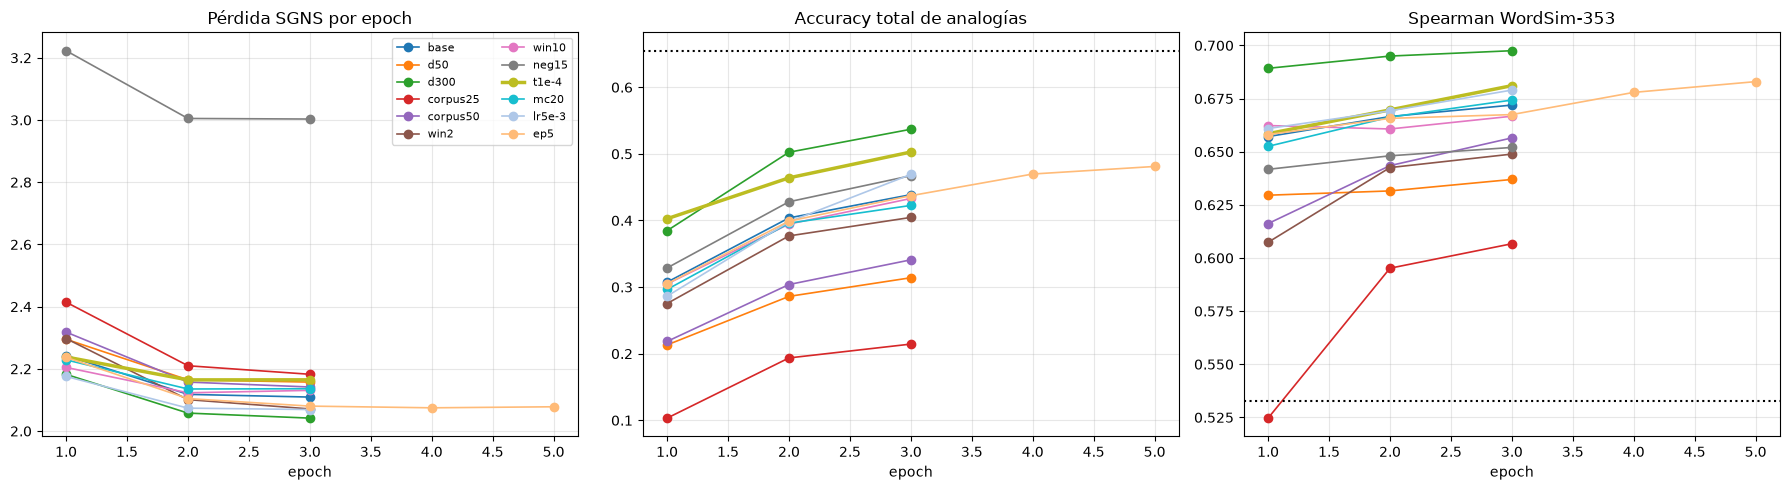

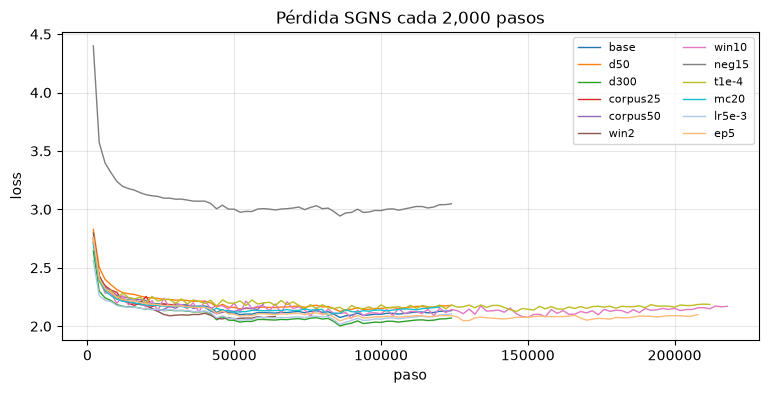

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, h in HIST.items():
    ep = [e["epoch"] for e in h["epochs"]]
    lw = 2.5 if name == BEST_NAME else 1.2
    axes[0].plot(ep, [e["loss"] for e in h["epochs"]], "o-", lw=lw, label=name)
    axes[1].plot(ep, [e["total"] for e in h["epochs"]], "o-", lw=lw, label=name)
    axes[2].plot(ep, [e["ws353"] for e in h["epochs"]], "o-", lw=lw, label=name)
axes[1].axhline(GLOVE_EVAL["total"], color="k", ls=":", label="GloVe-100")
axes[2].axhline(GLOVE_EVAL["ws353"], color="k", ls=":", label="GloVe-100")
for ax, t in zip(axes, ["Pérdida SGNS por epoch", "Accuracy total de analogías", "Spearman WordSim-353"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# Pérdida cada N pasos (promedio móvil por ventana de log_every pasos)
fig, ax = plt.subplots(figsize=(9, 4))
for name, h in HIST.items():
    if h["loss_steps"]:
        s, l = zip(*h["loss_steps"])
        ax.plot(s, l, lw=1, label=name)
ax.set_xlabel("paso"); ax.set_ylabel("loss"); ax.set_title("Pérdida SGNS cada 2,000 pasos"); ax.grid(alpha=.3)
ax.legend(fontsize=8, ncol=2); plt.show()

In [23]:
def tabla_vecinos(hist):
    return pd.DataFrame({f"epoch {e['epoch']}": {w: ", ".join(x for x, _ in v) for w, v in e["vecinos"].items()}
                         for e in hist["epochs"]})

print("Vecinos más cercanos por epoch — mejor configuración:", BEST_NAME)
tabla_vecinos(HIST[BEST_NAME])

Vecinos más cercanos por epoch — mejor configuración: t1e-4


,epoch 1,epoch 2,epoch 3
king,"vi, athelstan, bhumibol, bagrat, throne","theudebert, athelstan, fealty, harthacnut, haakon","theudebert, athelstan, bhumibol, haakon, uncrowned"
france,"spain, portugal, italy, belgium, netherlands","spain, belgium, portugal, italy, netherlands","spain, belgium, italy, netherlands, portugal"
computer,"computers, mainframe, software, simulation, labs","computers, mainframe, software, computing, simulation","computers, mainframe, software, simulation, computing"
good,"luck, excellent, bad, decent, thoughtfulness","bad, decent, excellent, luck, nice","bad, decent, luck, excellent, throw-away"
january,"february, march, december, november, april","december, february, november, april, march","february, december, november, march, april"
run,"inside-the-park, ninth-inning, walk-off, two-run, runs","running, inside-the-park, montee, ninth-inning, runs","running, runs, ran, inside-the-park, montee"


¿Una pérdida más baja implica siempre mejores embeddings?

No. Los resultados lo muestran de varias formas:

- La pérdida solo es comparable dentro de una misma configuración. Con `neg15` la pérdida final es 3.00 (contra 2.11 de `base`) simplemente porque se suman 15 términos negativos en lugar de 5, y aun así sus analogías son mejores (0.467 contra 0.439).
- Menor pérdida con peores embeddings: `win2` termina con pérdida 2.07, menor que `base` (2.11), pero su accuracy de analogías es menor (0.405 contra 0.439) y también su ρ en WordSim-353 (0.649 contra 0.672). Con ventana pequeña los contextos son más predecibles (vecinos inmediatos), así que la tarea es "más fácil" sin que el espacio sea mejor.
- Mayor pérdida con mejores embeddings: el mejor modelo de d=100, `t1e-4`, tiene pérdida 2.16 (mayor que `base`) y la mejor accuracy total entre las configuraciones de d=100 (0.503). Con un umbral de submuestreo menos agresivo se conservan más pares con palabras muy frecuentes (`the`, `of`), que además son los negativos más probables; distinguirlos es difícil, lo que sube la pérdida promedio, pero el modelo ve más contexto sintáctico (analogías sintácticas 0.569 contra 0.480).
- La pérdida se estanca mientras los embeddings siguen mejorando: en `ep5` la pérdida pasa de 2.080 (epoch 3) a 2.075 y luego 2.078 (epochs 4 y 5), prácticamente plana, mientras que la accuracy de analogías sube de 0.437 a 0.470 y a 0.481. La pérdida mide qué tan bien se predicen co-ocurrencias individuales, no qué tan regular (lineal) es la geometría del espacio.
- A veces sí coinciden: `d300` (2.04) y `lr5e-3` (2.07) tienen menor pérdida y mejores analogías que `base`, porque más capacidad o mejor optimización mejoran ambas cosas. Pero no es una regla.

Por eso la selección se hizo con WordSim-353 y analogías, no con la pérdida. Tampoco es comparable la pérdida de gensim: es una suma acumulada (no un promedio) y cambia con el número de workers.

### 4.3 Word2Vec de gensim (implementación de referencia)

Se entrena con la mejor configuración de SGNS: mismo archivo de corpus (el flujo de IDs convertido a texto, una secuencia por línea), mismo vocabulario y frecuencias (`build_vocab_from_freq`), misma ventana, negativos, umbral de submuestreo, dimensión y epochs. Diferencia inevitable: gensim usa SGD por par con `alpha` 0.025 → 0.0001 (lineal), mientras que SGNS propio usa SparseAdam por lotes.

Se entrena epoch por epoch para registrar las mismas métricas. No obstante, la pérdida que reporta gensim es una suma acumulada en `float32` (problema conocido: se satura alrededor de 1.3·10⁸), así que solo sirve como referencia cualitativa y no es comparable en escala con la pérdida media del SGNS propio.

También se entrena gensim con 25 %, 50 % y 100 % del corpus para la gráfica de accuracy vs. tamaño de corpus (sección 7).

In [24]:
GENSIM_WORKERS = max(1, multiprocessing.cpu_count() - 1)
GENSIM_FRACS = [0.25, 0.5, 1.0]
_USE_CORPUS_FILE = True

def corpus_file_for(frac):
    n_lines, n_tok = corpus_subset(frac)
    path = os.path.join(MODELS_DIR, f"corpus_{int(round(frac * 100))}.txt")
    if not os.path.exists(path):
        itos_np = np.array(itos, dtype=object)
        tmp = path + ".tmp"
        with open(tmp, "w", encoding="utf-8") as fh:
            for k in tqdm(range(n_lines), desc=f"escribiendo {path}"):
                fh.write(" ".join(itos_np[ids[OFFS[k]:OFFS[k + 1]]]) + "\n")
        os.replace(tmp, path)
    return path, n_lines, n_tok

def gensim_paths(cfg, frac):
    name = f"gensim_{cfg['name']}_c{int(round(frac * 100))}"
    return name, os.path.join(MODELS_DIR, f"{name}.kv"), os.path.join(MODELS_DIR, f"{name}.json")

def train_gensim(cfg, frac):
    global _USE_CORPUS_FILE
    name, kv_path, hist_path = gensim_paths(cfg, frac)
    if not FORCE_RETRAIN and os.path.exists(kv_path) and os.path.exists(hist_path):
        print(f"[caché] {name}: modelo ya entrenado, se carga el historial")
        return load_json(hist_path)

    path, n_lines, n_tok = corpus_file_for(frac)
    cnt_sub = np.bincount(ids[:n_tok], minlength=V)
    valid = cnt_sub >= cfg["min_count"]
    freq = {itos[i]: int(cnt_sub[i]) for i in np.flatnonzero(valid)}

    E, a_max, a_min = cfg["epochs"], 0.025, 1e-4
    model = Word2Vec(vector_size=cfg["dim"], window=cfg["window"], negative=cfg["neg"], sample=cfg["t"],
                     sg=1, hs=0, min_count=1, ns_exponent=0.75, alpha=a_max, min_alpha=a_min,
                     workers=GENSIM_WORKERS, seed=SEED, shrink_windows=True)
    model.build_vocab_from_freq(freq)
    hist = {"config": {**cfg, "frac": frac, "alpha": a_max, "min_alpha": a_min, "workers": GENSIM_WORKERS},
            "tokens_corpus": n_tok, "vocab_size": len(model.wv), "epochs": []}
    print(f"=== {name}: tokens {n_tok:,} | |V| {len(model.wv):,} | workers {GENSIM_WORKERS}")

    t_total = time.time()
    for ep in range(E):
        a0 = a_max - (a_max - a_min) * ep / E
        a1 = a_max - (a_max - a_min) * (ep + 1) / E
        t0 = time.time()
        kw = dict(epochs=1, start_alpha=a0, end_alpha=a1, compute_loss=True)
        if _USE_CORPUS_FILE:
            try:
                model.train(corpus_file=path, total_words=n_tok, **kw)
            except Exception as ex:
                print("corpus_file no disponible, se usa LineSentence:", ex)
                _USE_CORPUS_FILE = False
        if not _USE_CORPUS_FILE:
            model.train(corpus_iterable=LineSentence(path), total_examples=n_lines, **kw)
        t_ep = time.time() - t0
        m = evaluate_kv(model.wv)
        rec = {"epoch": ep + 1, "loss_gensim": float(model.get_latest_training_loss()), "tiempo_s": t_ep, **m}
        hist["epochs"].append(rec)
        print(f"[{name}] epoch {ep+1}/{E} | loss gensim {rec['loss_gensim']:.4g} | {t_ep:.0f}s")
        print_metrics("   ", m)

    hist["tiempo_entrenamiento_s"] = sum(e["tiempo_s"] for e in hist["epochs"])
    hist["tiempo_total_s"] = time.time() - t_total
    hist["hardware"] = CPU_NAME
    model.wv.save(kv_path)
    save_json(hist, hist_path)
    del model
    gc.collect()
    return hist

HIST_GENSIM = {}
for f in sorted(set(GENSIM_FRACS) | {BEST_CFG["frac"]}):
    HIST_GENSIM[f] = train_gensim(BEST_CFG, f)

[caché] gensim_t1e-4_c25: modelo ya entrenado, se carga el historial
[caché] gensim_t1e-4_c50: modelo ya entrenado, se carga el historial
[caché] gensim_t1e-4_c100: modelo ya entrenado, se carga el historial


,modelo,epoch,analog. sem,analog. sin,analog. total,WS353 ρ,tiempo epoch (s)
0,SGNS propio,1,0.2575,0.4715,0.4026,0.6585,239.3077
1,SGNS propio,2,0.3231,0.5308,0.4640,0.6697,215.5622
2,SGNS propio,3,0.3632,0.5690,0.5028,0.6811,202.5459
3,gensim,1,0.1607,0.2425,0.2162,0.5722,82.8568
4,gensim,2,0.2754,0.3788,0.3455,0.6470,82.2368
5,gensim,3,0.3471,0.5192,0.4638,0.6736,83.0635


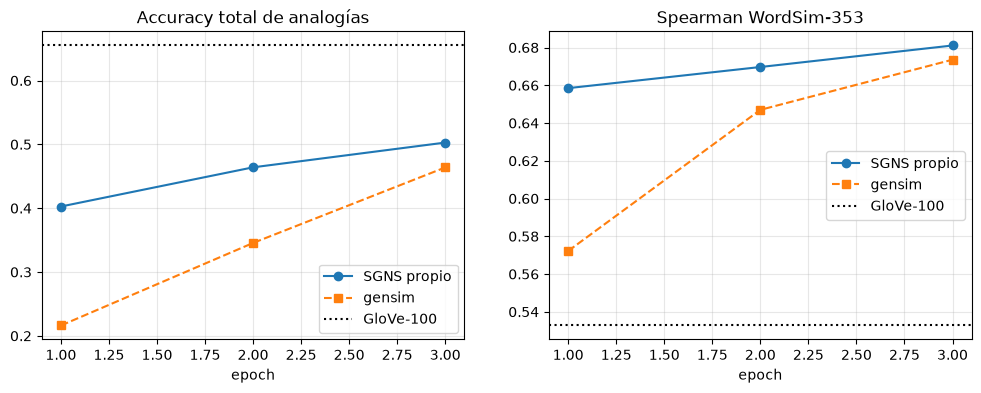

In [25]:
# Comparación por epoch: SGNS propio vs gensim (misma configuración, mismo corpus)
hs, hg = HIST[BEST_NAME], HIST_GENSIM[BEST_CFG["frac"]]
comp_rows = []
for tag, h in (("SGNS propio", hs), ("gensim", hg)):
    for e in h["epochs"]:
        comp_rows.append({"modelo": tag, "epoch": e["epoch"], "analog. sem": e["sem"], "analog. sin": e["syn"],
                          "analog. total": e["total"], "WS353 ρ": e["ws353"], "tiempo epoch (s)": e["tiempo_s"]})
display(pd.DataFrame(comp_rows).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tag, h, st in (("SGNS propio", hs, "o-"), ("gensim", hg, "s--")):
    ep = [e["epoch"] for e in h["epochs"]]
    axes[0].plot(ep, [e["total"] for e in h["epochs"]], st, label=tag)
    axes[1].plot(ep, [e["ws353"] for e in h["epochs"]], st, label=tag)
axes[0].axhline(GLOVE_EVAL["total"], color="k", ls=":", label="GloVe-100")
axes[1].axhline(GLOVE_EVAL["ws353"], color="k", ls=":", label="GloVe-100")
axes[0].set_title("Accuracy total de analogías"); axes[1].set_title("Spearman WordSim-353")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=.3); ax.legend()
plt.show()

### 4.4 Modelos finales y exportación

Se cargan los tres conjuntos de embeddings finales. El mejor SGNS se exporta además en formato word2vec `.txt` (entregable del repositorio).

In [26]:
kv_sgns = KeyedVectors.load(sgns_paths(BEST_NAME)[0])
kv_gensim = KeyedVectors.load(gensim_paths(BEST_CFG, BEST_CFG["frac"])[1])
EMBEDDINGS = {"SGNS": kv_sgns, "Gensim": kv_gensim, "GloVe": glove}
EMB_LABEL = {"SGNS": f"SGNS propio ({BEST_NAME})", "Gensim": "Word2Vec gensim", "GloVe": "GloVe-100 (preentrenado)"}

_txt = os.path.join(MODELS_DIR, "sgns_mejor_word2vec.txt")
if not os.path.exists(_txt):
    kv_sgns.save_word2vec_format(_txt, binary=False)
print("Vectores del mejor SGNS:", _txt, "y", sgns_paths(BEST_NAME)[0])

pd.DataFrame({EMB_LABEL[k]: {w: ", ".join(x for x, _ in kv.most_similar(w, topn=5)) if w in kv.key_to_index else "—"
                             for w in CONTROL_WORDS} for k, kv in EMBEDDINGS.items()})

Vectores del mejor SGNS: modelos\sgns_mejor_word2vec.txt y modelos\sgns_t1e-4.kv


,SGNS propio (t1e-4),Word2Vec gensim,GloVe-100 (preentrenado)
king,"theudebert, athelstan, bhumibol, haakon, uncrowned","eógan, ætheling, guthfrithson, donnchada, harthacnut","prince, queen, son, brother, monarch"
france,"spain, belgium, italy, netherlands, portugal","belgium, spain, portugal, italy, netherlands","belgium, french, britain, spain, paris"
computer,"computers, mainframe, software, simulation, computing","computers, computing, realtime, simulation, sgi","computers, software, technology, pc, hardware"
good,"bad, decent, luck, excellent, throw-away","decent, excellent, nerve-wracking, darn, crummy","better, sure, really, kind, very"
january,"february, december, november, march, april","february, june, april, november, march","december, october, february, november, september"
run,"running, runs, ran, inside-the-park, montee","running, 3-for-4, multi-home, whistle-stop, off-year","running, runs, ran, out, go"


# Inciso 5. Verificación de la aritmética vectorial



##  preparación

In [3]:
# ===== Inciso 5: preparación =====
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

SEED_5 = 42
SPECIALS = {"<pad>", "<unk>"}
MODELOS = list(EMBEDDINGS)                      # ["SGNS", "Gensim", "GloVe"]
pd.set_option("display.max_colwidth", None)

# Vectores normalizados (norma 1) de cada modelo: cos(u, v) = u · v
NORMED = {k: kv.get_normed_vectors().astype(np.float32) for k, kv in EMBEDDINGS.items()}
for k in MODELOS:
    print(f"{EMB_LABEL[k]:<28} |V| = {len(EMBEDDINGS[k].key_to_index):>8,}   dim = {NORMED[k].shape[1]}")

SGNS propio (t1e-4)          |V| =  195,026   dim = 100
Word2Vec gensim              |V| =  195,026   dim = 100
GloVe-100 (preentrenado)     |V| =  400,000   dim = 100


##  5.1 analogia(a, b, c, k) y verificación contra gensim

In [4]:
# ===== 5.1: analogía con 3CosAdd (implementación propia) =====
def _sims(a, b, c, modelo, excluir=True):
    """Similitud coseno de TODO el vocabulario con q = b - a + c (vectores normalizados)."""
    kv, E = EMBEDDINGS[modelo], NORMED[modelo]
    idx = [kv.key_to_index[w] for w in (a, b, c)]
    q = E[idx[1]] - E[idx[0]] + E[idx[2]]
    q = q / np.linalg.norm(q)
    sims = E @ q
    if excluir:
        sims[idx] = -np.inf                      # excluye a, b y c del resultado
    return sims, idx

def _topk(sims, modelo, k):
    top = np.argpartition(-sims, k)[:k]
    top = top[np.argsort(-sims[top])]
    kv = EMBEDDINGS[modelo]
    return [(kv.index_to_key[i], float(sims[i])) for i in top]

def analogia(a, b, c, k=5, modelo="SGNS", excluir=True):
    """«a es a b como c es a ?»  ->  top-k [(palabra, coseno con b - a + c)]"""
    sims, _ = _sims(a, b, c, modelo, excluir)
    return _topk(sims, modelo, k)

# 21 analogías, 7 tipos: (tipo, a, b, c, esperada)  =>  a : b :: c : esperada
ANALOGIAS_51 = [
    ("género", "king", "queen", "man", "woman"),
    ("género", "brother", "sister", "uncle", "aunt"),
    ("género", "father", "mother", "son", "daughter"),
    ("país–capital", "france", "paris", "italy", "rome"),
    ("país–capital", "japan", "tokyo", "germany", "berlin"),
    ("país–capital", "spain", "madrid", "egypt", "cairo"),
    ("país–capital", "canada", "ottawa", "greece", "athens"),
    ("país–gentilicio", "france", "french", "germany", "german"),
    ("país–gentilicio", "spain", "spanish", "japan", "japanese"),
    ("país–gentilicio", "poland", "polish", "sweden", "swedish"),
    ("comparativo", "good", "better", "bad", "worse"),
    ("comparativo", "big", "bigger", "small", "smaller"),
    ("comparativo", "fast", "faster", "slow", "slower"),
    ("superlativo", "good", "best", "bad", "worst"),
    ("superlativo", "big", "biggest", "small", "smallest"),
    ("tiempo verbal", "go", "went", "take", "took"),
    ("tiempo verbal", "write", "wrote", "speak", "spoke"),
    ("tiempo verbal", "play", "played", "walk", "walked"),
    ("plural", "car", "cars", "tree", "trees"),
    ("plural", "mouse", "mice", "child", "children"),
    ("plural", "city", "cities", "country", "countries"),
]

# ---- Verificación: ¿coincide con most_similar de gensim? ----
filas = []
for m in MODELOS:
    kv = EMBEDDINGS[m]
    n = ok_pal = ok_sim = 0
    for _, a, b, c, _e in ANALOGIAS_51:
        if any(w not in kv.key_to_index for w in (a, b, c)):
            continue
        mio = analogia(a, b, c, 5, m)
        ref = kv.most_similar(positive=[b, c], negative=[a], topn=5)
        n += 1
        ok_pal += [w for w, _ in mio] == [w for w, _ in ref]
        ok_sim += np.allclose([s for _, s in mio], [s for _, s in ref], atol=1e-4)
    filas.append({"modelo": EMB_LABEL[m], "analogías": n,
                  "mismo top-5 (palabras y orden)": f"{ok_pal}/{n}", "mismas similitudes (tol 1e-4)": f"{ok_sim}/{n}"})
display(pd.DataFrame(filas))

,modelo,analogías,mismo top-5 (palabras y orden),mismas similitudes (tol 1e-4)
0,SGNS propio (t1e-4),21,21/21,21/21
1,Word2Vec gensim,21,21/21,21/21
2,GloVe-100 (preentrenado),21,21/21,21/21


Implementamos analogia(a, b, c, k) con 3CosAdd. Normalizamos todos los vectores a norma 1, construimos q = vec(b) − vec(a) + vec(c), lo normalizamos, calculamos el coseno de q con todo el vocabulario mediante un producto matricial y excluimos a, b y c antes de tomar los k mejores. Verificamos la función contra most_similar(positive=[b, c], negative=[a]) de gensim con las 21 analogías en los tres modelos. En los tres, 21 de 21 casos coinciden en las palabras y en su orden, y las similitudes coinciden con tolerancia de 1e-4. Esto es esperable, porque most_similar hace lo mismo internamente: normaliza los vectores, combina positivos y negativos, normaliza el resultado y excluye las palabras de la consulta.

##  5.1 evaluación de las 21 analogías (top-5, rango, coseno)

In [5]:
# ===== 5.1: top-5, rango y coseno de la respuesta correcta =====
def evaluar_analogia(modelo, tipo, a, b, c, esperada, excluir=True, k=5):
    kv = EMBEDDINGS[modelo]
    if any(w not in kv.key_to_index for w in (a, b, c, esperada)):
        return None
    sims, _ = _sims(a, b, c, modelo, excluir)
    ie = kv.key_to_index[esperada]
    top = _topk(sims, modelo, k)
    return {"modelo": modelo, "tipo": tipo, "analogía": f"{a}:{b} :: {c}:?", "esperada": esperada,
            "top-5": ", ".join(f"{w} ({s:.3f})" for w, s in top), "top": top,
            "rango": int((sims > sims[ie]).sum()) + 1,       # posición de la correcta en todo el vocabulario
            "cos_correcta": float(sims[ie])}                 # coseno(esperada, b - a + c)

res, omitidas = [], []
for m in MODELOS:
    for caso in ANALOGIAS_51:
        r = evaluar_analogia(m, *caso)
        (res if r else omitidas).append(r or (m, caso))
res = pd.DataFrame(res)
if omitidas:
    print("Omitidas por palabras fuera del vocabulario del modelo:", [(m, c[1:]) for m, c in omitidas])

cols = ["tipo", "analogía", "esperada", "top-5", "rango", "cos_correcta"]
for m in MODELOS:
    print(f"\n=== {EMB_LABEL[m]} ===")
    display(res[res.modelo == m][cols].reset_index(drop=True).round(3))

resumen_51 = res.groupby("modelo").agg(
    n=("rango", "size"),
    acc_top1=("rango", lambda r: (r == 1).mean()),
    acc_top5=("rango", lambda r: (r <= 5).mean()),
    MRR=("rango", lambda r: (1 / r).mean()),
    rango_mediano=("rango", "median"),
    cos_correcta_media=("cos_correcta", "mean")).loc[MODELOS]
resumen_51.index = [EMB_LABEL[m] for m in resumen_51.index]
print("\nResumen 5.1 (con exclusión de a, b, c)")
display(resumen_51.round(3))

print("Accuracy top-1 por tipo de analogía")
display(res.assign(ok=res.rango == 1).pivot_table(index="tipo", columns="modelo", values="ok", aggfunc="mean")[MODELOS].round(2))


=== SGNS propio (t1e-4) ===


,tipo,analogía,esperada,top-5,rango,cos_correcta
0,género,king:queen :: man:?,woman,"woman (0.769), dark-haired (0.698), girl (0.695), red-haired (0.686), blonde (0.668)",1,0.769
1,género,brother:sister :: uncle:?,aunt,"aunt (0.726), sisters (0.721), half-sister (0.712), dorothea (0.705), grandmother (0.686)",1,0.726
2,género,father:mother :: son:?,daughter,"daughter (0.906), wife (0.852), eldest (0.833), grandmother (0.815), daughters (0.799)",1,0.906
3,país–capital,france:paris :: italy:?,rome,"vienna (0.800), prague (0.793), düsseldorf (0.769), berlin (0.762), bucharest (0.752)",23,0.685
4,país–capital,japan:tokyo :: germany:?,berlin,"berlin (0.816), munich (0.785), düsseldorf (0.782), frankfurt (0.773), budapest (0.772)",1,0.816
5,país–capital,spain:madrid :: egypt:?,cairo,"egyptian (0.693), baghdad (0.673), cairo (0.655), gaza (0.634), syria (0.628)",3,0.655
6,país–capital,canada:ottawa :: greece:?,athens,"greeks (0.662), greek (0.661), macedon (0.652), macedonia (0.639), macedonian (0.638)",12,0.616
7,país–gentilicio,france:french :: germany:?,german,"german (0.895), austrian (0.803), russian (0.783), dutch (0.761), swedish (0.736)",1,0.895
8,país–gentilicio,spain:spanish :: japan:?,japanese,"japanese (0.819), philippine (0.638), korean (0.629), chinese (0.620), tokyo (0.614)",1,0.819
9,país–gentilicio,poland:polish :: sweden:?,swedish,"swedish (0.864), finnish (0.809), danish (0.751), finland (0.739), czech (0.731)",1,0.864



=== Word2Vec gensim ===


,tipo,analogía,esperada,top-5,rango,cos_correcta
0,género,king:queen :: man:?,woman,"woman (0.698), girl (0.651), blonde (0.557), schoolgirl (0.551), women (0.546)",1,0.698
1,género,brother:sister :: uncle:?,aunt,"sisters (0.669), half-sister (0.660), half-sisters (0.633), great-grandsons (0.620), nieces (0.618)",27,0.588
2,género,father:mother :: son:?,daughter,"daughter (0.804), grandchild (0.773), eldest (0.771), daughters (0.765), stillborn (0.756)",1,0.804
3,país–capital,france:paris :: italy:?,rome,"rome (0.721), vienna (0.715), prague (0.711), bucharest (0.697), perugia (0.686)",1,0.721
4,país–capital,japan:tokyo :: germany:?,berlin,"berlin (0.756), munich (0.747), cologne (0.736), düsseldorf (0.731), graz (0.728)",1,0.756
5,país–capital,spain:madrid :: egypt:?,cairo,"egyptian (0.651), gaza (0.642), mesopotamia (0.620), baghdad (0.612), najaf (0.605)",8,0.589
6,país–capital,canada:ottawa :: greece:?,athens,"athens (0.700), sparta (0.678), elis (0.656), crete (0.651), aegina (0.642)",1,0.700
7,país–gentilicio,france:french :: germany:?,german,"german (0.808), russian (0.748), austrian (0.727), dutch (0.705), swedish (0.698)",1,0.808
8,país–gentilicio,spain:spanish :: japan:?,japanese,"japanese (0.732), peke (0.627), korean (0.626), paka (0.608), taiwanese (0.606)",1,0.732
9,país–gentilicio,poland:polish :: sweden:?,swedish,"swedish (0.780), finnish (0.743), danish (0.706), finland (0.690), czech (0.674)",1,0.780



=== GloVe-100 (preentrenado) ===


,tipo,analogía,esperada,top-5,rango,cos_correcta
0,género,king:queen :: man:?,woman,"woman (0.818), girl (0.747), she (0.695), her (0.672), mother (0.671)",1,0.818
1,género,brother:sister :: uncle:?,aunt,"aunt (0.865), grandmother (0.800), mother (0.798), daughter (0.778), niece (0.768)",1,0.865
2,género,father:mother :: son:?,daughter,"daughter (0.953), wife (0.887), sister (0.843), niece (0.820), husband (0.819)",1,0.953
3,país–capital,france:paris :: italy:?,rome,"rome (0.819), milan (0.738), naples (0.712), venice (0.702), turin (0.700)",1,0.819
4,país–capital,japan:tokyo :: germany:?,berlin,"frankfurt (0.843), berlin (0.819), munich (0.730), paris (0.711), vienna (0.694)",2,0.819
5,país–capital,spain:madrid :: egypt:?,cairo,"cairo (0.803), egyptian (0.714), amman (0.668), damascus (0.621), hosni (0.610)",1,0.803
6,país–capital,canada:ottawa :: greece:?,athens,"athens (0.669), thessaloniki (0.653), aek (0.649), panathinaikos (0.641), paok (0.636)",1,0.669
7,país–gentilicio,france:french :: germany:?,german,"german (0.960), austrian (0.777), swiss (0.766), swedish (0.734), polish (0.726)",1,0.960
8,país–gentilicio,spain:spanish :: japan:?,japanese,"japanese (0.917), korean (0.774), chinese (0.677), tokyo (0.615), asian (0.600)",1,0.917
9,país–gentilicio,poland:polish :: sweden:?,swedish,"swedish (0.909), danish (0.778), finnish (0.761), norwegian (0.760), austrian (0.720)",1,0.909



Resumen 5.1 (con exclusión de a, b, c)


,n,acc_top1,acc_top5,MRR,rango_mediano,cos_correcta_media
SGNS propio (t1e-4),21,0.714,0.857,0.786,1.0,0.748
Word2Vec gensim,21,0.667,0.762,0.721,1.0,0.680
GloVe-100 (preentrenado),21,0.810,0.952,0.885,1.0,0.828


Accuracy top-1 por tipo de analogía


modelo,SGNS,Gensim,GloVe
tipo,,,
comparativo,0.67,0.67,0.67
género,1.00,0.67,1.00
país–capital,0.25,0.75,0.75
país–gentilicio,1.00,1.00,1.00
plural,1.00,0.67,1.00
superlativo,0.00,0.00,0.50
tiempo verbal,1.00,0.67,0.67


Evaluamos 21 analogías de siete tipos: género, país–capital, país–gentilicio, comparativos, superlativos, tiempos verbales y plurales. Las tablas por modelo muestran el top-5 con sus similitudes, el rango de la respuesta correcta y su coseno con el vector resultante. El top-1 fue de 0.714 para SGNS, 0.667 para gensim y 0.810 para GloVe. En el top-5 fue de 0.857, 0.762 y 0.952, y el MRR fue de 0.786, 0.721 y 0.885. El coseno medio de la respuesta correcta con el vector resultante fue de 0.748, 0.680 y 0.828 respectivamente. Es decir, aun cuando la respuesta es correcta, el vector resultante no coincide con ella, porque el coseno queda en torno a 0.7–0.8.

Por tipo, país–gentilicio fue perfecto en los tres modelos (accuracy top-1 de 1.0). Género, plurales y tiempos verbales fueron muy buenos en SGNS y GloVe. Los superlativos fueron lo más difícil: 0/2 en SGNS y gensim, y 1/2 en GloVe. good:best :: bad:? devuelve awards y razzie en lugar de worst, porque en Wikipedia best aparece sobre todo en contextos de premios ("Best Actor"), así que el desplazamiento arrastra esa polisemia. big:biggest :: small:? devuelve large y largest en lugar de smallest. En país–capital el SGNS tuvo solo 1/4: france:paris :: italy:? devuelve vienna y prague antes que rome (la correcta queda en el rango 23), y para egypt el primer resultado es egyptian. El modelo captura la relación "capital europea" pero no la asocia bien con cada país, probablemente por la escasez de ejemplos en un corpus pequeño. Gensim tuvo casos con rangos muy altos, como worst (rango 174) y smallest (rango 134). Con solo 21 casos, las diferencias de uno o dos aciertos entre modelos no son concluyentes, y la evaluación sistemática de 5.2 es más confiable.

## 5.1 repetir sin excluir a, b, c

In [6]:
# ===== 5.1: sin excluir las palabras de la consulta =====
filas = []
for m in MODELOS:
    for tipo, a, b, c, e in ANALOGIAS_51:
        r = evaluar_analogia(m, tipo, a, b, c, e, excluir=False)
        if r is None:
            continue
        w1, s1 = r["top"][0]
        quien = ("b" if w1 == b else "c" if w1 == c else "a" if w1 == a
                 else "correcta" if w1 == e else "otra")
        filas.append({"modelo": m, "analogía": r["analogía"], "top1": w1, "top1_es": quien,
                      "cos_top1": s1, "rango_correcta": r["rango"]})
sin_excl = pd.DataFrame(filas)

print("¿Qué palabra queda en 1.er lugar sin excluir a, b, c? (% de analogías)")
display((pd.crosstab(sin_excl.modelo, sin_excl.top1_es, normalize="index") * 100).reindex(MODELOS).round(1))
print("Accuracy top-1 sin exclusión:", sin_excl.assign(ok=sin_excl.top1_es == "correcta").groupby("modelo").ok.mean().reindex(MODELOS).round(3).to_dict())
print("Coseno medio del top-1 sin exclusión:", sin_excl.groupby("modelo").cos_top1.mean().reindex(MODELOS).round(3).to_dict())

# Caso clásico king - man + woman
for m in MODELOS:
    print(f"\n[{EMB_LABEL[m]}]")
    print("  con exclusión:", [(w, round(s, 3)) for w, s in analogia("man", "king", "woman", 5, m, True)])
    print("  sin exclusión:", [(w, round(s, 3)) for w, s in analogia("man", "king", "woman", 5, m, False)])

¿Qué palabra queda en 1.er lugar sin excluir a, b, c? (% de analogías)


top1_es,b,c,correcta,otra
modelo,,,,
SGNS,23.8,33.3,33.3,9.5
Gensim,23.8,57.1,19.0,0.0
GloVe,9.5,23.8,52.4,14.3


Accuracy top-1 sin exclusión: {'SGNS': 0.333, 'Gensim': 0.19, 'GloVe': 0.524}
Coseno medio del top-1 sin exclusión: {'SGNS': 0.804, 'Gensim': 0.767, 'GloVe': 0.857}

[SGNS propio (t1e-4)]
  con exclusión: [('queen', 0.737), ('regnant', 0.714), ('haakon', 0.674), ('mongkut', 0.667), ('throne', 0.665)]
  sin exclusión: [('king', 0.812), ('queen', 0.737), ('regnant', 0.714), ('haakon', 0.674), ('mongkut', 0.667)]

[Word2Vec gensim]
  con exclusión: [('eanflæd', 0.669), ('daughter-in-law', 0.668), ('regnant', 0.668), ('lady-in-waiting', 0.662), ('consort', 0.661)]
  sin exclusión: [('king', 0.733), ('eanflæd', 0.669), ('daughter-in-law', 0.668), ('regnant', 0.668), ('lady-in-waiting', 0.662)]

[GloVe-100 (preentrenado)]
  con exclusión: [('queen', 0.77), ('monarch', 0.684), ('throne', 0.676), ('daughter', 0.659), ('princess', 0.652)]
  sin exclusión: [('king', 0.836), ('queen', 0.77), ('monarch', 0.684), ('throne', 0.676), ('daughter', 0.659)]


Sin excluir las palabras de la consulta, el primer lugar casi nunca es una respuesta nueva. Con SGNS, el top-1 fue b en el 23.8 % de los casos y c en el 33.3 %; con gensim fue b en el 23.8 % y c en el 57.1 %; con GloVe fue b en el 9.5 % y c en el 23.8 %. La respuesta correcta quedó primero solo en el 33.3 % (SGNS), 19.0 % (gensim) y 52.4 % (GloVe), frente a 71.4 %, 66.7 % y 81.0 % con exclusión. En el ejemplo clásico king − man + woman, el primer lugar es king en los tres modelos (similitudes de 0.812, 0.733 y 0.836), y queen queda en segundo lugar en SGNS (0.737) y GloVe (0.770). En gensim queen ni siquiera aparece en el top-5, y el modelo devuelve palabras raras como eanflæd y regnant. El coseno medio del top-1 sin exclusión (0.804, 0.767 y 0.857) es mayor que el de la respuesta correcta con exclusión. Esto indica que b − a + c queda muy cerca de las palabras de entrada y que la operación es solo un desplazamiento pequeño hacia la respuesta. La aritmética funciona como una búsqueda aproximada de vecinos tras un desplazamiento, y buena parte del accuracy reportado depende de excluir las palabras de la consulta.

## 5.2 vocabulario compartido y preguntas

In [7]:
# ===== 5.2: vocabulario compartido (30k más frecuentes presentes en los 3 modelos) =====
VOCAB_COMPARTIDO = 30_000
# index_to_key de SGNS está ordenado por frecuencia (corpus propio)
COMPARTIDO = [w for w in EMBEDDINGS["SGNS"].index_to_key
              if w not in SPECIALS and all(w in EMBEDDINGS[k].key_to_index for k in MODELOS)][:VOCAB_COMPARTIDO]
W2I = {w: i for i, w in enumerate(COMPARTIDO)}
ESH = {k: NORMED[k][[EMBEDDINGS[k].key_to_index[w] for w in COMPARTIDO]] for k in MODELOS}   # (30000, d)
print(f"Vocabulario compartido: {len(COMPARTIDO):,} palabras | ejemplo: {COMPARTIDO[:8]}")

def leer_preguntas(path):
    secs, cur = {}, None
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip().lower()
            if line.startswith(":"):
                cur = line[1:].strip(); secs[cur] = []
            elif line:
                secs[cur].append(tuple(line.split()))
    return secs

QS_ALL = leer_preguntas(analogias)
QS_OK = {s: np.array([[W2I[w] for w in q] for q in qs if all(w in W2I for w in q)],
                     dtype=np.int64).reshape(-1, 4) for s, qs in QS_ALL.items()}
n_tot, n_ok = sum(map(len, QS_ALL.values())), sum(map(len, QS_OK.values()))
print(f"Preguntas totales: {n_tot:,} | evaluadas (4 palabras en el vocab. compartido): {n_ok:,} "
      f"| cobertura global: {100*n_ok/n_tot:.1f}% | categorías: {len(QS_ALL)}")

Vocabulario compartido: 30,000 palabras | ejemplo: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on']
Preguntas totales: 19,544 | evaluadas (4 palabras en el vocab. compartido): 12,170 | cobertura global: 62.3% | categorías: 14


El vocabulario compartido son las 30,000 palabras más frecuentes (según el orden de frecuencia del corpus propio) presentes en los tres modelos, así que las preguntas evaluadas son las mismas para todos. De las 19,544 preguntas, se evaluaron 12,170, una cobertura global de 62.3 %. La cobertura es mucho menor en las categorías semánticas (44.1 %, 3,915 de 8,869) que en las sintácticas (77.3 %, 8,255 de 10,675). Las más afectadas son currency (10.2 %), capital-world (26.8 %) y gram2-opposite (42.1 %), porque incluyen palabras raras (monedas, capitales de países pequeños, derivados poco comunes) que quedan fuera de las 30,000 más frecuentes. Por eso las cifras semánticas representan sobre todo palabras frecuentes y no son directamente comparables con las del inciso 4, donde el vocabulario se restringía por modelo.

Con 3CosAdd, el accuracy total fue de 0.503 para SGNS, 0.464 para gensim y 0.656 para GloVe. En las semánticas fue de 0.363, 0.347 y 0.606, y en las sintácticas de 0.569, 0.519 y 0.680. GloVe gana con claridad en las categorías semánticas, como capital-common-countries (0.937 contra 0.571 de SGNS) y capital-world (0.892 contra 0.409). Esa brecha es coherente con la diferencia de datos de entrenamiento: unos 60 veces más tokens para GloVe. En las sintácticas la brecha es menor, y SGNS y gensim superan a GloVe en gram7-past-tense (0.685 y 0.652 contra 0.588). El SGNS propio supera a gensim en casi todas las categorías (0.503 contra 0.464 en total). La excepción es capital-world (0.409 contra 0.431), y esa diferencia es modesta.

Las categorías más difíciles fueron currency (entre 0 y 4.5 % de accuracy, sobre solo 88 preguntas evaluadas), city-in-state (0.23–0.31), gram1-adjective-to-adverb (0.21–0.30) y gram2-opposite (0.24–0.25). Las más fáciles fueron gram6-nationality-adjective (0.837, 0.790 y 0.973) y, para GloVe, capital-common-countries, capital-world y family. 3CosMul no mejoró a 3CosAdd: dio 0.478, 0.431 y 0.638 en total, contra 0.503, 0.464 y 0.656. Solo fue mejor en unos pocos casos aislados (por ejemplo gram9-plural-verbs en SGNS y gram4-superlative en GloVe), con diferencias de uno o dos puntos. Un resultado más favorable a 3CosMul, como el que reportan Levy y Goldberg, quizá requeriría vectores de mayor dimensión o más datos.

## 5.2 accuracy por categoría con 3CosAdd y 3CosMul → ANALOGIAS_52

,categoría,tipo,total,evaluadas,cobertura %,SGNS 3CosAdd,SGNS 3CosMul,Gensim 3CosAdd,Gensim 3CosMul,GloVe 3CosAdd,GloVe 3CosMul
0,capital-common-countries,sem,506,462,91.304,0.571,0.571,0.569,0.552,0.937,0.920
1,capital-world,sem,4524,1213,26.813,0.409,0.389,0.431,0.386,0.892,0.862
2,currency,sem,866,88,10.162,0.011,0.023,0.000,0.000,0.045,0.034
3,city-in-state,sem,2467,1810,73.368,0.244,0.233,0.231,0.219,0.306,0.270
4,family,sem,506,342,67.589,0.640,0.602,0.450,0.436,0.880,0.868
5,gram1-adjective-to-adverb,syn,992,756,76.210,0.224,0.192,0.214,0.168,0.295,0.295
6,gram2-opposite,syn,812,342,42.118,0.246,0.152,0.240,0.173,0.254,0.222
7,gram3-comparative,syn,1332,1260,94.595,0.696,0.679,0.615,0.606,0.800,0.782
8,gram4-superlative,syn,1122,702,62.567,0.397,0.397,0.336,0.333,0.608,0.613
9,gram5-present-participle,syn,1056,870,82.386,0.530,0.476,0.460,0.399,0.721,0.716


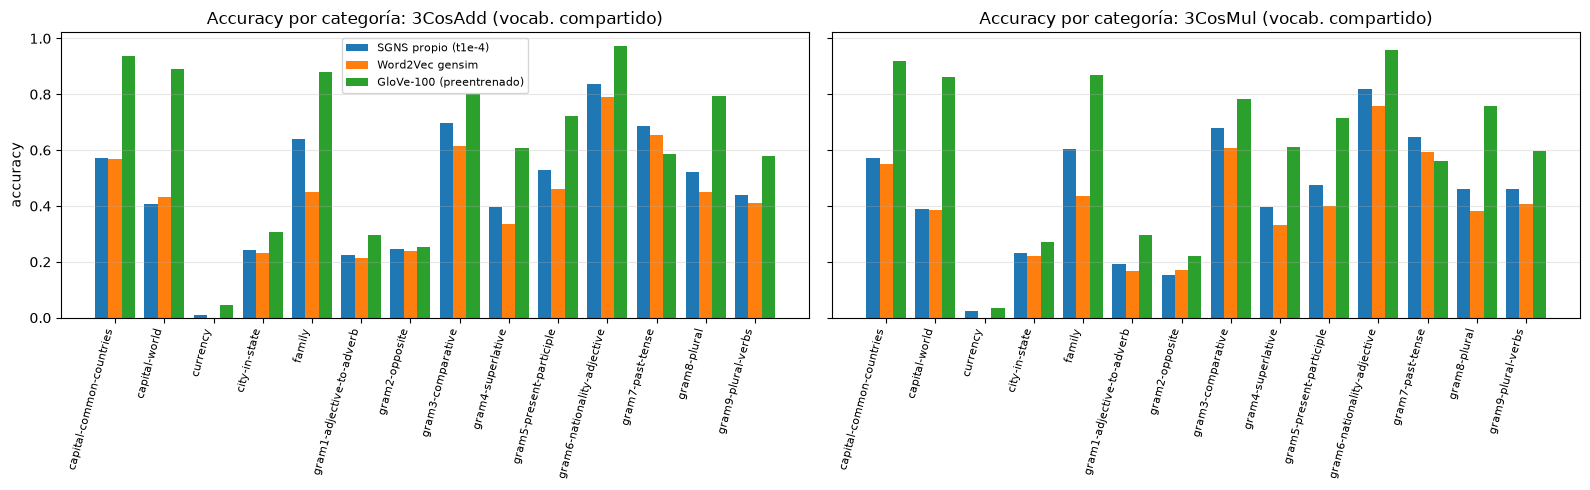

ANALOGIAS_52 = {'SGNS': {'add': {'sem': 0.3632, 'syn': 0.569, 'total': 0.5028}, 'mul': {'sem': 0.3489, 'syn': 0.5391, 'total': 0.4779}}, 'Gensim': {'add': {'sem': 0.3469, 'syn': 0.5192, 'total': 0.4638}, 'mul': {'sem': 0.3241, 'syn': 0.4815, 'total': 0.4309}}, 'GloVe': {'add': {'sem': 0.6061, 'syn': 0.6801, 'total': 0.6563}, 'mul': {'sem': 0.577, 'syn': 0.6665, 'total': 0.6377}}}


In [8]:
# ===== 5.2: 3CosAdd y 3CosMul sobre el vocabulario compartido =====
def correctas(E, Q, metodo, batch=512):
    """Q: (n,4) índices a,b,c,d. Candidatos = todo el vocabulario compartido, excluyendo a, b, c."""
    ia, ib, ic, idd = Q.T
    ok = np.zeros(len(Q), dtype=bool)
    for s in range(0, len(Q), batch):
        sl = slice(s, s + batch)
        A, B, C = E[ia[sl]], E[ib[sl]], E[ic[sl]]
        if metodo == "add":                              # argmax cos(d,b) - cos(d,a) + cos(d,c)
            sc = (B - A + C) @ E.T
        else:                                            # 3CosMul (Levy & Goldberg, 2014), cos desplazado a [0,1]
            sa, sb, sc_ = ((X @ E.T + 1) / 2 for X in (A, B, C))
            sc = sb * sc_ / (sa + 1e-3)
        r = np.arange(len(A))
        for M in (ia[sl], ib[sl], ic[sl]):
            sc[r, M] = -np.inf
        ok[sl] = sc.argmax(1) == idd[sl]
    return ok

RES52 = {(k, met, s): (correctas(ESH[k], Q, met) if len(Q) else np.zeros(0, bool))
         for k in MODELOS for met in ("add", "mul") for s, Q in QS_OK.items()}

tipo_de = lambda s: "syn" if s.startswith("gram") else "sem"

def acc_grupo(k, met, tipo=None):
    cs = [RES52[(k, met, s)] for s in QS_ALL if tipo is None or tipo_de(s) == tipo]
    cs = np.concatenate(cs)
    return float(cs.mean()) if len(cs) else float("nan")

ANALOGIAS_52 = {k: {met: {"sem": acc_grupo(k, met, "sem"), "syn": acc_grupo(k, met, "syn"),
                          "total": acc_grupo(k, met)} for met in ("add", "mul")} for k in MODELOS}

filas = []
for s in QS_ALL:
    f = {"categoría": s, "tipo": tipo_de(s), "total": len(QS_ALL[s]), "evaluadas": len(QS_OK[s]),
         "cobertura %": 100 * len(QS_OK[s]) / len(QS_ALL[s])}
    for k in MODELOS:
        for met, nom in (("add", "3CosAdd"), ("mul", "3CosMul")):
            c = RES52[(k, met, s)]
            f[f"{k} {nom}"] = c.mean() if len(c) else np.nan
    filas.append(f)
for nombre, tipo in (("SEMÁNTICAS", "sem"), ("SINTÁCTICAS", "syn"), ("TOTAL", None)):
    ss = [s for s in QS_ALL if tipo is None or tipo_de(s) == tipo]
    tot, ev = sum(len(QS_ALL[s]) for s in ss), sum(len(QS_OK[s]) for s in ss)
    f = {"categoría": nombre, "tipo": tipo or "", "total": tot, "evaluadas": ev, "cobertura %": 100 * ev / tot}
    for k in MODELOS:
        for met, nom in (("add", "3CosAdd"), ("mul", "3CosMul")):
            f[f"{k} {nom}"] = acc_grupo(k, met, tipo)
    filas.append(f)
tabla52 = pd.DataFrame(filas)
display(tabla52.round(3))

# Gráfica por categoría
cats = list(QS_ALL)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (met, nom) in zip(axes, (("add", "3CosAdd"), ("mul", "3CosMul"))):
    x, w = np.arange(len(cats)), 0.27
    for j, k in enumerate(MODELOS):
        ax.bar(x + (j - 1) * w, [np.nan if not len(RES52[(k, met, s)]) else RES52[(k, met, s)].mean() for s in cats],
               w, label=EMB_LABEL[k])
    ax.set_xticks(x); ax.set_xticklabels(cats, rotation=75, ha="right", fontsize=8)
    ax.set_title(f"Accuracy por categoría: {nom} (vocab. compartido)"); ax.grid(alpha=.3, axis="y")
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("ANALOGIAS_52 =", {k: {m: {f: round(v, 4) for f, v in d.items()} for m, d in v.items()} for k, v in ANALOGIAS_52.items()})

## paralelismo → PARALELISMO

In [9]:
# ===== Paralelismo: coseno promedio entre vectores diferencia (b - a) de una misma relación =====
def paralelismo_cos(E, pares):
    D = E[pares[:, 1]] - E[pares[:, 0]]
    D = D / np.linalg.norm(D, axis=1, keepdims=True)
    n = len(D)
    G = D @ D.T
    return float((G.sum() - n) / (n * (n - 1)))            # promedio fuera de la diagonal

def pares_unicos(Q):
    return np.unique(np.vstack([Q[:, [0, 1]], Q[:, [2, 3]]]), axis=0)

filas, rng = [], np.random.default_rng(SEED_5)
rand = rng.integers(0, len(COMPARTIDO), size=(1500, 2)); rand = rand[rand[:, 0] != rand[:, 1]]
for s, Q in QS_OK.items():
    if len(Q) == 0:
        continue
    P = pares_unicos(Q)
    if len(P) < 2:
        continue
    f = {"categoría": s, "pares únicos": len(P)}
    for k in MODELOS:
        f[k] = paralelismo_cos(ESH[k], P)
    filas.append(f)
par_df = pd.DataFrame(filas)

PARALELISMO = {k: float(par_df[k].mean()) for k in MODELOS}      # promedio sobre categorías
base = {k: paralelismo_cos(ESH[k], rand) for k in MODELOS}       # referencia: pares de palabras al azar

resumen_par = pd.DataFrame({"PARALELISMO (media de categorías)": PARALELISMO,
                            "base aleatoria (pares al azar)": base}).T[MODELOS]
display(par_df.round(3))
display(resumen_par.round(3))

,categoría,pares únicos,SGNS,Gensim,GloVe
0,capital-common-countries,22,0.413,0.364,0.586
1,capital-world,60,0.337,0.288,0.561
2,currency,10,0.237,0.200,0.260
3,city-in-state,58,0.240,0.192,0.336
4,family,19,0.324,0.257,0.507
5,gram1-adjective-to-adverb,28,0.154,0.144,0.282
6,gram2-opposite,19,0.123,0.118,0.227
7,gram3-comparative,36,0.366,0.317,0.422
8,gram4-superlative,27,0.324,0.281,0.465
9,gram5-present-participle,30,0.212,0.193,0.319


,SGNS,Gensim,GloVe
PARALELISMO (media de categorías),0.291,0.249,0.405
base aleatoria (pares al azar),-0.000,-0.000,-0.000


## t-SNE de ~500 palabras (mejor modelo)

498 palabras en 17 grupos (modelo: SGNS propio (t1e-4))


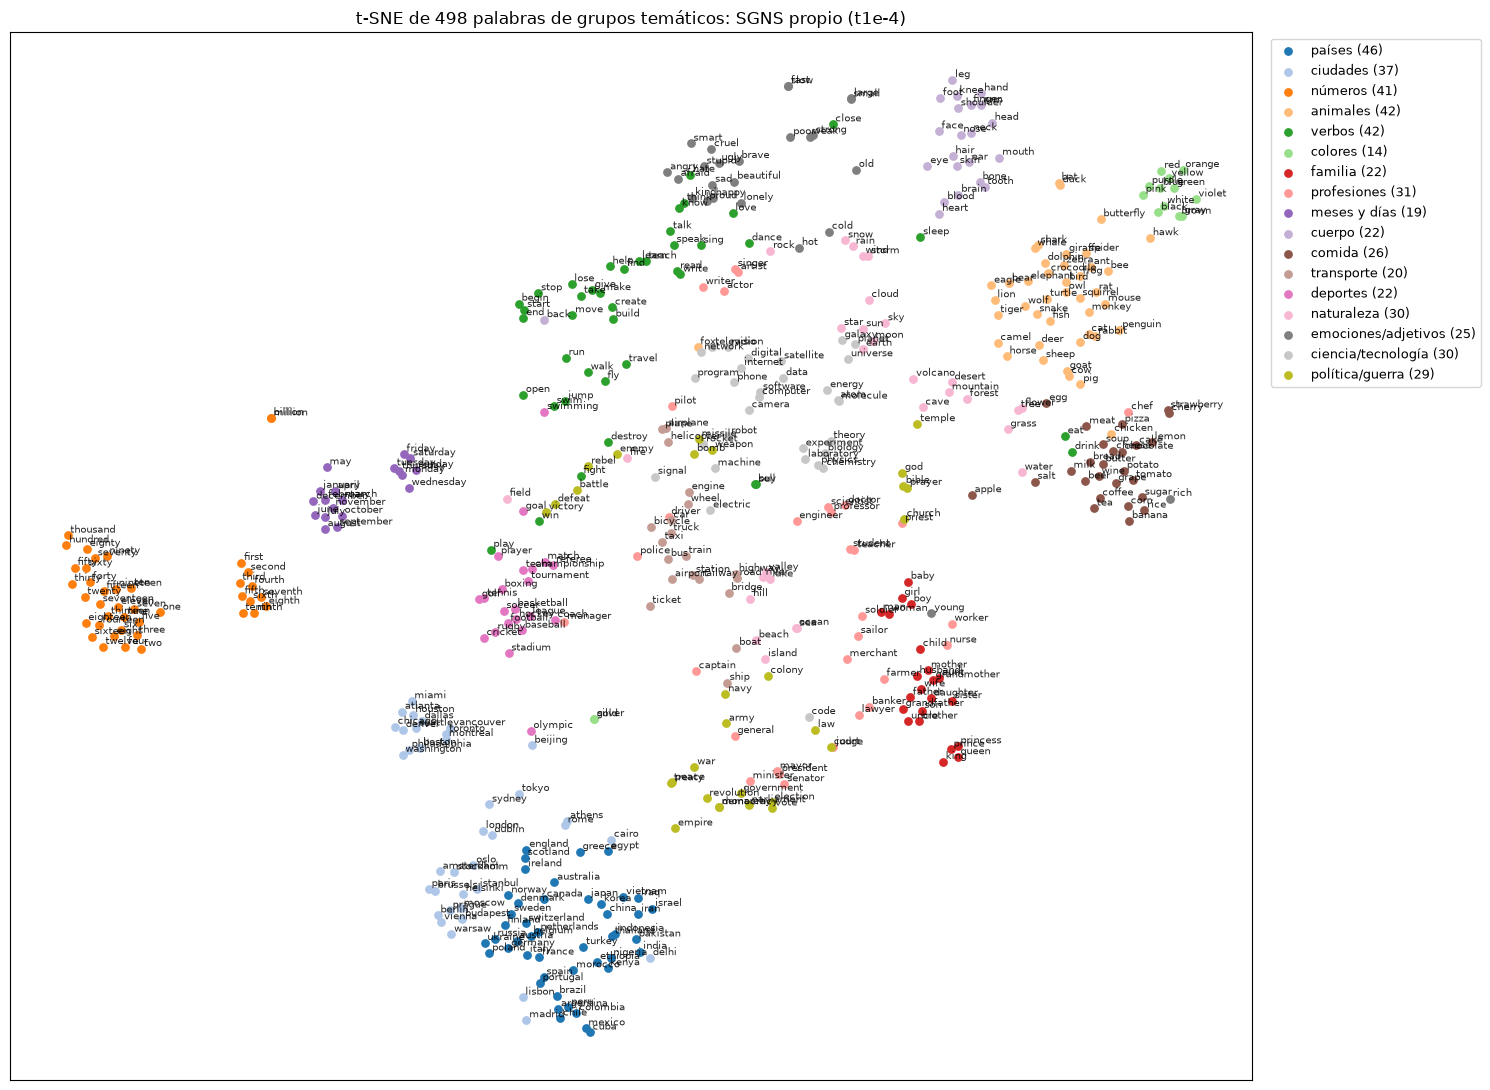

Pureza de los 10 vecinos más cercanos (misma etiqueta): media = 0.736
Silhouette (coseno, etiquetas temáticas): 0.193


,pureza kNN (k=10)
profesiones,0.397
naturaleza,0.487
política/guerra,0.517
emociones/adjetivos,0.568
verbos,0.605
ciencia/tecnología,0.613
transporte,0.615
cuerpo,0.782
comida,0.792
ciudades,0.814


In [10]:
# ===== 5.2: t-SNE de grupos temáticos (mejor modelo: SGNS) =====
GRUPOS = {
 "países": "france germany italy spain portugal england scotland ireland poland russia ukraine sweden norway finland denmark netherlands belgium switzerland austria greece turkey egypt china japan india korea thailand vietnam indonesia australia canada mexico brazil argentina chile peru colombia cuba iran iraq israel pakistan nigeria kenya ethiopia morocco".split(),
 "ciudades": "paris london berlin rome madrid moscow tokyo beijing delhi cairo athens vienna lisbon dublin warsaw prague budapest stockholm oslo helsinki amsterdam brussels istanbul sydney toronto chicago boston seattle houston dallas atlanta miami denver philadelphia washington montreal vancouver".split(),
 "números": "one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty thirty forty fifty sixty seventy eighty ninety hundred thousand million billion first second third fourth fifth sixth seventh eighth ninth tenth".split(),
 "animales": "dog cat horse cow pig sheep goat chicken duck rabbit mouse rat lion tiger bear wolf fox deer elephant monkey snake frog fish shark whale dolphin eagle owl bird butterfly bee ant spider turtle crocodile zebra giraffe camel squirrel bat penguin hawk".split(),
 "verbos": "run walk jump swim fly eat drink sleep read write speak talk think know learn teach build create destroy buy sell give take make find lose win play sing dance open close begin end start stop move travel fight love hate help".split(),
 "colores": "red blue green yellow orange purple pink black white gray brown silver gold violet".split(),
 "familia": "father mother brother sister son daughter uncle aunt grandfather grandmother husband wife king queen prince princess man woman boy girl child baby".split(),
 "profesiones": "doctor nurse teacher lawyer engineer scientist artist writer singer actor farmer soldier police pilot driver chef judge priest banker merchant sailor mayor president minister senator general captain professor student worker manager".split(),
 "meses y días": "january february march april may june july august september october november december monday tuesday wednesday thursday friday saturday sunday".split(),
 "cuerpo": "head hand arm leg foot eye ear nose mouth heart brain hair face finger knee shoulder neck back skin blood bone tooth".split(),
 "comida": "apple banana grape lemon cherry strawberry bread cheese milk rice meat egg butter sugar salt coffee tea wine beer potato tomato corn soup cake chocolate pizza".split(),
 "transporte": "car bus train plane ship boat bicycle truck airplane helicopter road bridge railway airport station ticket engine wheel highway taxi".split(),
 "deportes": "football soccer baseball basketball tennis golf hockey rugby cricket boxing swimming olympic championship tournament team player coach match goal league referee stadium".split(),
 "naturaleza": "river mountain lake ocean sea forest desert island valley hill tree flower grass rain snow wind storm sun moon star cloud fire water earth sky beach cave volcano field rock".split(),
 "emociones/adjetivos": "happy sad angry afraid proud lonely brave kind cruel strong weak rich poor young old beautiful ugly smart stupid fast slow hot cold large small".split(),
 "ciencia/tecnología": "computer software internet network data program code machine robot electric energy atom molecule physics chemistry biology planet galaxy universe theory experiment laboratory satellite rocket signal digital camera phone television radio".split(),
 "política/guerra": "church temple god prayer bible war peace army navy battle treaty election government parliament law court vote weapon bomb missile enemy victory defeat revolution rebel empire treaty colony monarchy democracy".split(),
}
TSNE_MODELO = "SGNS"
kv_t = EMBEDDINGS[TSNE_MODELO]
palabras, etiquetas, vistos = [], [], set()
for g, ws in GRUPOS.items():
    for w in ws:
        if w in kv_t.key_to_index and w not in vistos:
            vistos.add(w); palabras.append(w); etiquetas.append(g)
etiquetas = np.array(etiquetas)
X = NORMED[TSNE_MODELO][[kv_t.key_to_index[w] for w in palabras]]
print(f"{len(palabras)} palabras en {len(GRUPOS)} grupos (modelo: {EMB_LABEL[TSNE_MODELO]})")

Z = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=SEED_5).fit_transform(X)

cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(15, 11))
for i, g in enumerate(GRUPOS):
    m = etiquetas == g
    ax.scatter(Z[m, 0], Z[m, 1], s=28, color=cmap(i % 20), label=f"{g} ({m.sum()})")
for (x, y), w in zip(Z, palabras):
    ax.annotate(w, (x, y), fontsize=7, alpha=.85, xytext=(2, 2), textcoords="offset points")
ax.set_title(f"t-SNE de {len(palabras)} palabras de grupos temáticos: {EMB_LABEL[TSNE_MODELO]}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# Medida cuantitativa (en el espacio original, no en el 2D de t-SNE)
S = X @ X.T
np.fill_diagonal(S, -np.inf)
vecinos = np.argsort(-S, axis=1)[:, :10]
mismo = etiquetas[vecinos] == etiquetas[:, None]
pureza = pd.Series(mismo.mean(1), index=etiquetas).groupby(level=0).mean().sort_values()
print(f"Pureza de los 10 vecinos más cercanos (misma etiqueta): media = {mismo.mean():.3f}")
print(f"Silhouette (coseno, etiquetas temáticas): {silhouette_score(X, etiquetas, metric='cosine'):.3f}")
display(pureza.round(3).to_frame("pureza kNN (k=10)"))

Proyectamos con t-SNE 498 palabras de 17 grupos temáticos usando el mejor modelo, el SGNS propio. Los grupos se forman en gran medida, aunque no todos con la misma nitidez. La pureza media de los 10 vecinos más cercanos (calculada en el espacio original de 100 dimensiones, no en el 2D) fue de 0.736, es decir, el 74 % de los vecinos pertenece al mismo grupo, muy por encima del azar (alrededor de 0.06 con 17 grupos). El silhouette con distancia coseno fue de 0.193, positivo pero bajo, lo que indica solapamiento entre grupos. Los grupos más compactos fueron números (0.959), meses y días (0.937), países (0.928), familia (0.886), colores (0.871), deportes (0.859) y animales (0.855). Son conjuntos cerrados cuyas palabras aparecen en contextos muy parecidos. Los menos definidos fueron profesiones (0.397), naturaleza (0.487), política/guerra (0.517) y emociones/adjetivos (0.568). Son grupos abstractos o polisémicos, y varios de sus términos son vecinos naturales de otros grupos. Por ejemplo, president, general y captain se confunden con política/guerra, y island o valley se mezclan con lugares. Países y ciudades también tienden a acercarse entre sí (cada ciudad cerca de su país), lo que baja la pureza aunque semánticamente tenga sentido. Conviene recordar que en t-SNE las distancias entre clusters y sus tamaños no son interpretables, por lo que la figura es ilustrativa y las métricas anteriores son las que respaldan la conclusión.

# Inciso 6. Pipeline end-to-end: clasificación de AG News

Preprocesamiento (mismo que la sección 2): minúsculas, tokenizador propio (`my_tokenize`) y eliminación de tokens que son solo puntuación. Ajustes para que los tokens coincidan con las convenciones de WikiText y GloVe (estilo Penn Treebank):

- AG News trae entidades HTML rotas (`#39;s`, `quot;`, `&lt;b&gt;`): se reparan y se quitan etiquetas HTML.
- Las contracciones se separan como en WikiText/GloVe: `don't → do n't`, `it's → it 's`.
- Las abreviaturas con puntos recuperan el punto final que el tokenizador separa: `u.s → u.s.`

Partición: 10 % estratificado del train oficial como validación; el test oficial solo se usa una vez por inicialización (mejor variante).

Clasificador: `nn.EmbeddingBag(mode="mean")` → `Linear(d, 256)` → ReLU → Dropout(0.3) → `Linear(256, 4)`. Vocabulario propio del clasificador construido con el train (frecuencia ≥ 2). En las variantes con tabla preentrenada, las palabras cubiertas toman su vector y las no cubiertas se inicializan aleatoriamente. En la variante congelada los tokens sin vector preentrenado se descartan del promedio (un vector aleatorio congelado solo añadiría ruido). Adam (lr = 1e-3), batch 256, early stopping sobre F1 macro de validación.

In [27]:
import html
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix,
                             ConfusionMatrixDisplay, log_loss)
import joblib

AG_CLASSES = news["train"].features["label"].names
ENT_RE = re.compile(r"(?<!&)(quot|amp|lt|gt|#\d+);")
TAG_RE = re.compile(r"<[^>]*>")
CLITIC_RE = re.compile(r"^(.+?)(n't|'s|'re|'ve|'ll|'d|'m)$")
ABBR_RE = re.compile(r"^(?:[a-z]\.)+[a-z]$")
SPACED_CLITIC_RE = re.compile(r"\s+'(s|re|ve|ll|d|m|t)\b")   # AG News escribe "Google #39;s" (con espacio)

def clean_news(text):
    t = html.unescape(ENT_RE.sub(r"&\1;", text))
    t = TAG_RE.sub(" ", t).replace("\\", " ")
    t = t.lower().replace("\u2019", "'").replace("\u2018", "'")
    return SPACED_CLITIC_RE.sub(r"'\1", t)            # "google 's" -> "google's" -> (después) "google" + "'s"

def tokenize_news(text):
    out = []
    for tok in my_tokenize(clean_news(text)):
        m = CLITIC_RE.match(tok)
        parts = [m.group(1), m.group(2)] if m else [tok]
        for p in parts:
            if ABBR_RE.match(p):
                p += "."
            if not is_punct(p):
                out.append(p)
    return out

ejemplo = news["train"][0]["text"]
print(ejemplo, "\n->", tokenize_news(ejemplo))
print(tokenize_news("Oil #39;s price: The U.S. didn't say quot;no quot; &lt;b&gt;today&lt;/b&gt;"))

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. 
-> ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short-sellers', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', 'are', 'seeing', 'green', 'again']
['oil', "'s", 'price', 'the', 'u.s.', 'did', "n't", 'say', 'no', 'today']


In [28]:
t0 = time.time()
ag_train_tok = [tokenize_news(t) for t in tqdm(news["train"]["text"], desc="AG train")]
ag_test_tok = [tokenize_news(t) for t in tqdm(news["test"]["text"], desc="AG test")]
y_all = np.fromiter(news["train"]["label"], dtype=np.int64)
y_test = np.fromiter(news["test"]["label"], dtype=np.int64)

idx_tr, idx_va = train_test_split(np.arange(len(y_all)), test_size=0.10, stratify=y_all, random_state=SEED)
y_va = y_all[idx_va]
print(f"train {len(idx_tr):,} | val {len(idx_va):,} | test {len(y_test):,} | {time.time()-t0:.0f}s")
print("Distribución de clases (val):", np.bincount(y_va))

AG test: 100%|██████████| 7600/7600 [00:00<00:00, 18840.49it/s]


train 108,000 | val 12,000 | test 7,600 | 8s
Distribución de clases (val): [3000 3000 3000 3000]


In [ ]:
#  Porcentaje de tokens de AG News fuera del vocabulario de cada conjunto de embeddings 
cnt_ag_tr = Counter(w for i in idx_tr for w in ag_train_tok[i])
cnt_ag_te = Counter(w for toks in ag_test_tok for w in toks)
cnt_ag_all = Counter(w for toks in ag_train_tok for w in toks) + cnt_ag_te

def oov_pct(counter, vocab):
    tot = sum(counter.values())
    return 100 * sum(c for w, c in counter.items() if w not in vocab) / tot

def oov_types_pct(counter, vocab):
    return 100 * sum(1 for w in counter if w not in vocab) / len(counter)

OOV_AG = {}
oov_rows = []
for key, kv in EMBEDDINGS.items():
    voc = kv.key_to_index
    OOV_AG[key] = oov_pct(cnt_ag_all, voc)
    oov_rows.append({"embeddings": EMB_LABEL[key], "|V| embeddings": len(voc),
                     "% tokens OOV (train)": oov_pct(cnt_ag_tr, voc),
                     "% tokens OOV (test)": oov_pct(cnt_ag_te, voc),
                     "% tokens OOV (todo AG News)": OOV_AG[key],
                     "% tipos OOV (todo AG News)": oov_types_pct(cnt_ag_all, voc)})
_ag_voc = {w for w, c in cnt_ag_tr.items() if c >= 2}
oov_rows.append({"embeddings": "Vocab. propio AG train (aleatorio, freq ≥ 2)", "|V| embeddings": len(_ag_voc),
                 "% tokens OOV (train)": oov_pct(cnt_ag_tr, _ag_voc), "% tokens OOV (test)": oov_pct(cnt_ag_te, _ag_voc),
                 "% tokens OOV (todo AG News)": np.nan, "% tipos OOV (todo AG News)": np.nan})
pd.DataFrame(oov_rows).round(2)

,embeddings,|V| embeddings,% tokens OOV (train),% tokens OOV (test),% tokens OOV (todo AG News),% tipos OOV (todo AG News)
0,SGNS propio (t1e-4),195026,2.28,2.24,2.28,38.98
1,Word2Vec gensim,195026,2.28,2.24,2.28,38.98
2,GloVe-100 (preentrenado),400000,0.93,0.90,0.92,25.05
3,"Vocab. propio AG train (aleatorio, freq ≥ 2)",49466,0.79,1.41,NaN,NaN


In [ ]:
# Utilidades del clasificador 
def build_ag_vocab(train_idx, min_freq):
    c = Counter()
    for i in train_idx:
        c.update(ag_train_tok[i])
    itos_ag = [PAD, UNK] + [w for w, n in c.most_common() if n >= min_freq]
    return itos_ag, {w: i for i, w in enumerate(itos_ag)}

def encode(token_lists, stoi_ag, allowed=None):
    """Formato CSR para EmbeddingBag: (ids concatenados, offsets de longitud n+1)."""
    seqs = [np.fromiter((stoi_ag.get(w, 1) for w in toks), dtype=np.int64, count=len(toks)) for toks in token_lists]
    if allowed is not None:
        seqs = [s[allowed[s]] for s in seqs]
    lens = np.fromiter((len(s) for s in seqs), dtype=np.int64, count=len(seqs))
    flat = np.concatenate(seqs) if len(seqs) else np.zeros(0, np.int64)
    return flat, np.concatenate([[0], np.cumsum(lens)])

def make_batch(flat, offs, idx):
    lens = offs[idx + 1] - offs[idx]
    f = np.concatenate([flat[offs[i]:offs[i + 1]] for i in idx])
    o = np.concatenate([[0], np.cumsum(lens)[:-1]])
    return torch.from_numpy(f).to(DEVICE), torch.from_numpy(o).to(DEVICE)

def init_matrix(itos_ag, kv, dim, rng):
    if kv is None:                                               # inicialización aleatoria N(0,1), como nn.EmbeddingBag
        M, covered = rng.normal(0, 1, (len(itos_ag), dim)), None
    else:
        M = rng.normal(0, float(kv.vectors[::20].std()), (len(itos_ag), dim))
        covered = np.zeros(len(itos_ag), dtype=bool)
        for i, w in enumerate(itos_ag):
            j = kv.key_to_index.get(w)
            if j is not None:
                M[i] = kv.vectors[j]; covered[i] = True
    M[0] = 0.0
    return M.astype(np.float32), covered

class BagClassifier(nn.Module):
    def __init__(self, emb_matrix, freeze, hidden=256, dropout=0.3, n_classes=4):
        super().__init__()
        self.emb = nn.EmbeddingBag.from_pretrained(torch.from_numpy(emb_matrix), freeze=freeze,
                                                   mode="mean", padding_idx=0)
        self.mlp = nn.Sequential(nn.Linear(emb_matrix.shape[1], hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, n_classes))

    def forward(self, flat, offsets):
        return self.mlp(self.emb(flat, offsets))

@torch.no_grad()
def predict(model, flat, offs, y, batch_size=2048):
    model.eval()
    preds, loss = [], 0.0
    for s in range(0, len(y), batch_size):
        idx = np.arange(s, min(s + batch_size, len(y)))
        f, o = make_batch(flat, offs, idx)
        logits = model(f, o)
        loss += F.cross_entropy(logits, torch.from_numpy(y[idx]).to(DEVICE), reduction="sum").item()
        preds.append(logits.argmax(1).cpu().numpy())
    return loss / len(y), np.concatenate(preds)

def clf_metrics(y, p):
    pr, rc, f1, _ = precision_recall_fscore_support(y, p, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y, p), "precision": pr, "recall": rc, "f1": f1}

def epochs_for(frac):
    """(max_epochs, patience): más epochs cuando hay pocos datos (pocos pasos por epoch)."""
    if frac >= 0.25:
        return 10, 3
    if frac >= 0.05:
        return 25, 5
    return 60, 8

def clf_name(slug, frac):
    return f"{slug}_f{frac:g}"

In [31]:
def run_classifier(name, kv, freeze, train_idx, frac=1.0, batch_size=256, lr=1e-3, verbose=True):
    ckpt = os.path.join(MODELS_DIR, f"clf_{name}.pt")
    hpath = os.path.join(MODELS_DIR, f"clf_{name}.json")
    rng = np.random.default_rng(SEED)
    torch.manual_seed(SEED)
    max_epochs, patience = epochs_for(frac)
    if freeze:      # solo se entrena el MLP: converge más lento, se le dan más epochs
        max_epochs, patience = 3 * max_epochs, patience + 2

    min_freq = 2 if len(train_idx) >= 10_000 else 1
    itos_ag, stoi_ag = build_ag_vocab(train_idx, min_freq)
    dim = 100 if kv is None else kv.vector_size
    M, covered = init_matrix(itos_ag, kv, dim, rng)
    allowed = covered if (freeze and covered is not None) else None
    va = encode([ag_train_tok[i] for i in idx_va], stoi_ag, allowed)
    te = encode(ag_test_tok, stoi_ag, allowed)

    model = BagClassifier(M, freeze).to(DEVICE)
    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    res = {"tipo": "nn", "model": model, "val": va, "test": te}

    if not FORCE_RETRAIN and os.path.exists(ckpt) and os.path.exists(hpath):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        res["hist"] = load_json(hpath)
        if verbose:
            print(f"[caché] {name}")
        return res

    tr = encode([ag_train_tok[i] for i in train_idx], stoi_ag, allowed)
    ytr = y_all[train_idx]
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    hist = {"nombre": name, "params_totales": n_total, "params_entrenables": n_train, "|V| clasificador": len(itos_ag),
            "n_train": len(train_idx), "epochs": []}
    best_f1, best_state, bad = -1.0, None, 0
    t0 = time.time()
    for ep in range(max_epochs):
        model.train()
        perm = rng.permutation(len(train_idx))
        tl = 0.0
        for s in range(0, len(perm), batch_size):
            b = perm[s:s + batch_size]
            f, o = make_batch(tr[0], tr[1], b)
            loss = F.cross_entropy(model(f, o), torch.from_numpy(ytr[b]).to(DEVICE))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            tl += loss.item() * len(b)
        vl, pv = predict(model, va[0], va[1], y_va)
        rec = {"epoch": ep + 1, "train_loss": tl / len(perm), "val_loss": vl, **clf_metrics(y_va, pv)}
        hist["epochs"].append(rec)
        if verbose:
            print(f"[{name}] ep {ep+1:>2} | train {rec['train_loss']:.4f} | val {vl:.4f} | "
                  f"acc {rec['accuracy']:.4f} | F1 {rec['f1']:.4f}")
        if rec["f1"] > best_f1:
            best_f1, bad = rec["f1"], 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            hist["mejor_epoch"] = ep + 1
        else:
            bad += 1
            if bad >= patience:
                break
    hist["tiempo_s"] = time.time() - t0
    model.load_state_dict(best_state)
    hist["val"] = hist["epochs"][hist["mejor_epoch"] - 1]
    torch.save(best_state, ckpt)
    save_json(hist, hpath)
    res["hist"] = hist
    return res


def run_tfidf(name, train_idx):
    path = os.path.join(MODELS_DIR, f"clf_{name}.joblib")
    hpath = os.path.join(MODELS_DIR, f"clf_{name}.json")
    if not FORCE_RETRAIN and os.path.exists(path) and os.path.exists(hpath):
        vec, clf = joblib.load(path)
        return {"tipo": "tfidf", "vec": vec, "clf": clf, "hist": load_json(hpath)}
    docs_tr = [" ".join(ag_train_tok[i]) for i in train_idx]
    docs_va = [" ".join(ag_train_tok[i]) for i in idx_va]
    ytr = y_all[train_idx]
    t0 = time.time()
    vec = TfidfVectorizer(token_pattern=r"\S+", lowercase=False, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    Xtr = vec.fit_transform(docs_tr)
    clf = LogisticRegression(max_iter=1000, C=10.0)
    clf.fit(Xtr, ytr)
    t_fit = time.time() - t0
    if hasattr(vec, "stop_words_"):
        vec.stop_words_ = None                           # ahorra memoria/disco (solo guarda términos podados)
    Xva = vec.transform(docs_va)
    pva = clf.predict(Xva)
    hist = {"nombre": name, "params_totales": int(clf.coef_.size + clf.intercept_.size),
            "params_entrenables": int(clf.coef_.size + clf.intercept_.size), "n_features": Xtr.shape[1],
            "n_train": len(train_idx), "tiempo_s": t_fit, "mejor_epoch": None,
            "train_logloss": log_loss(ytr, clf.predict_proba(Xtr), labels=[0, 1, 2, 3]),
            "val_logloss": log_loss(y_va, clf.predict_proba(Xva), labels=[0, 1, 2, 3]),
            "val": clf_metrics(y_va, pva)}
    joblib.dump((vec, clf), path)
    save_json(hist, hpath)
    return {"tipo": "tfidf", "vec": vec, "clf": clf, "hist": hist}


def predict_test(res):
    if res["tipo"] == "tfidf":
        return res["clf"].predict(res["vec"].transform([" ".join(t) for t in ag_test_tok]))
    flat, offs = res["test"]
    return predict(res["model"], flat, offs, y_test)[1]

In [ ]:
#  Entrenamiento de todos los modelos (100 % del train) 
# (etiqueta, slug, embeddings, congelado). El slug incluye el nombre de la mejor config. SGNS para que la caché sea coherente.
KINDS = [
    ("TF-IDF + LR",            "tfidf",                    None,      None),
    ("Aleatorio (entrenable)", "random_ft",                None,      False),
    ("SGNS congelado",         f"sgns-{BEST_NAME}_frz",    kv_sgns,   True),
    ("SGNS fine-tuning",       f"sgns-{BEST_NAME}_ft",     kv_sgns,   False),
    ("Gensim congelado",       f"gensim-{BEST_NAME}_frz",  kv_gensim, True),
    ("Gensim fine-tuning",     f"gensim-{BEST_NAME}_ft",   kv_gensim, False),
    ("GloVe congelado",        "glove_frz",                glove,     True),
    ("GloVe fine-tuning",      "glove_ft",                 glove,     False),
]

def run_kind(label, slug, kv, freeze, frac, train_idx, verbose=True):
    if slug == "tfidf":
        return run_tfidf(clf_name(slug, frac), train_idx)
    return run_classifier(clf_name(slug, frac), kv, freeze, train_idx, frac=frac, verbose=verbose)

RES = {}
for label, slug, kv, freeze in KINDS:
    print(f"--- {label}")
    RES[label] = run_kind(label, slug, kv, freeze, 1.0, idx_tr)

--- TF-IDF + LR
--- Aleatorio (entrenable)
[random_ft_f1] ep  1 | train 0.6777 | val 0.4007 | acc 0.8642 | F1 0.8637
[random_ft_f1] ep  2 | train 0.3420 | val 0.3261 | acc 0.8924 | F1 0.8924
[random_ft_f1] ep  3 | train 0.2688 | val 0.2966 | acc 0.9045 | F1 0.9044
[random_ft_f1] ep  4 | train 0.2257 | val 0.2831 | acc 0.9062 | F1 0.9059
[random_ft_f1] ep  5 | train 0.1935 | val 0.2783 | acc 0.9098 | F1 0.9098
[random_ft_f1] ep  6 | train 0.1672 | val 0.2798 | acc 0.9108 | F1 0.9108
[random_ft_f1] ep  7 | train 0.1451 | val 0.2918 | acc 0.9104 | F1 0.9103
[random_ft_f1] ep  8 | train 0.1251 | val 0.3033 | acc 0.9093 | F1 0.9092
[random_ft_f1] ep  9 | train 0.1085 | val 0.3225 | acc 0.9083 | F1 0.9082
--- SGNS congelado
[sgns-t1e-4_frz_f1] ep  1 | train 0.5453 | val 0.3808 | acc 0.8724 | F1 0.8722
[sgns-t1e-4_frz_f1] ep  2 | train 0.3755 | val 0.3600 | acc 0.8766 | F1 0.8765
[sgns-t1e-4_frz_f1] ep  3 | train 0.3611 | val 0.3490 | acc 0.8787 | F1 0.8784
[sgns-t1e-4_frz_f1] ep  4 | train 0

In [33]:
val_rows = []
for label, r in RES.items():
    h = r["hist"]
    val_rows.append({"modelo": label, **{k: h["val"][k] for k in ("accuracy", "precision", "recall", "f1")},
                     "mejor epoch": h["mejor_epoch"], "params totales": h["params_totales"],
                     "params entrenables": h["params_entrenables"], "tiempo (s)": h["tiempo_s"]})
tabla_val = pd.DataFrame(val_rows)
tabla_val.round(4)

,modelo,accuracy,precision,recall,f1,mejor epoch,params totales,params entrenables,tiempo (s)
0,TF-IDF + LR,0.9222,0.9220,0.9222,0.9220,NaN,1691564,1691564,29.3749
1,Aleatorio (entrenable),0.9108,0.9111,0.9108,0.9108,6.0,4973684,4973684,12.4693
2,SGNS congelado,0.8947,0.8954,0.8947,0.8946,29.0,4973684,26884,20.0506
3,SGNS fine-tuning,0.9211,0.9210,0.9211,0.9209,3.0,4973684,4973684,8.2196
4,Gensim congelado,0.8959,0.8959,0.8959,0.8956,27.0,4973684,26884,19.5665
5,Gensim fine-tuning,0.9216,0.9216,0.9216,0.9214,3.0,4973684,4973684,8.0063
6,GloVe congelado,0.9095,0.9097,0.9095,0.9094,28.0,4973684,26884,20.0710
7,GloVe fine-tuning,0.9217,0.9217,0.9217,0.9215,3.0,4973684,4973684,8.2853


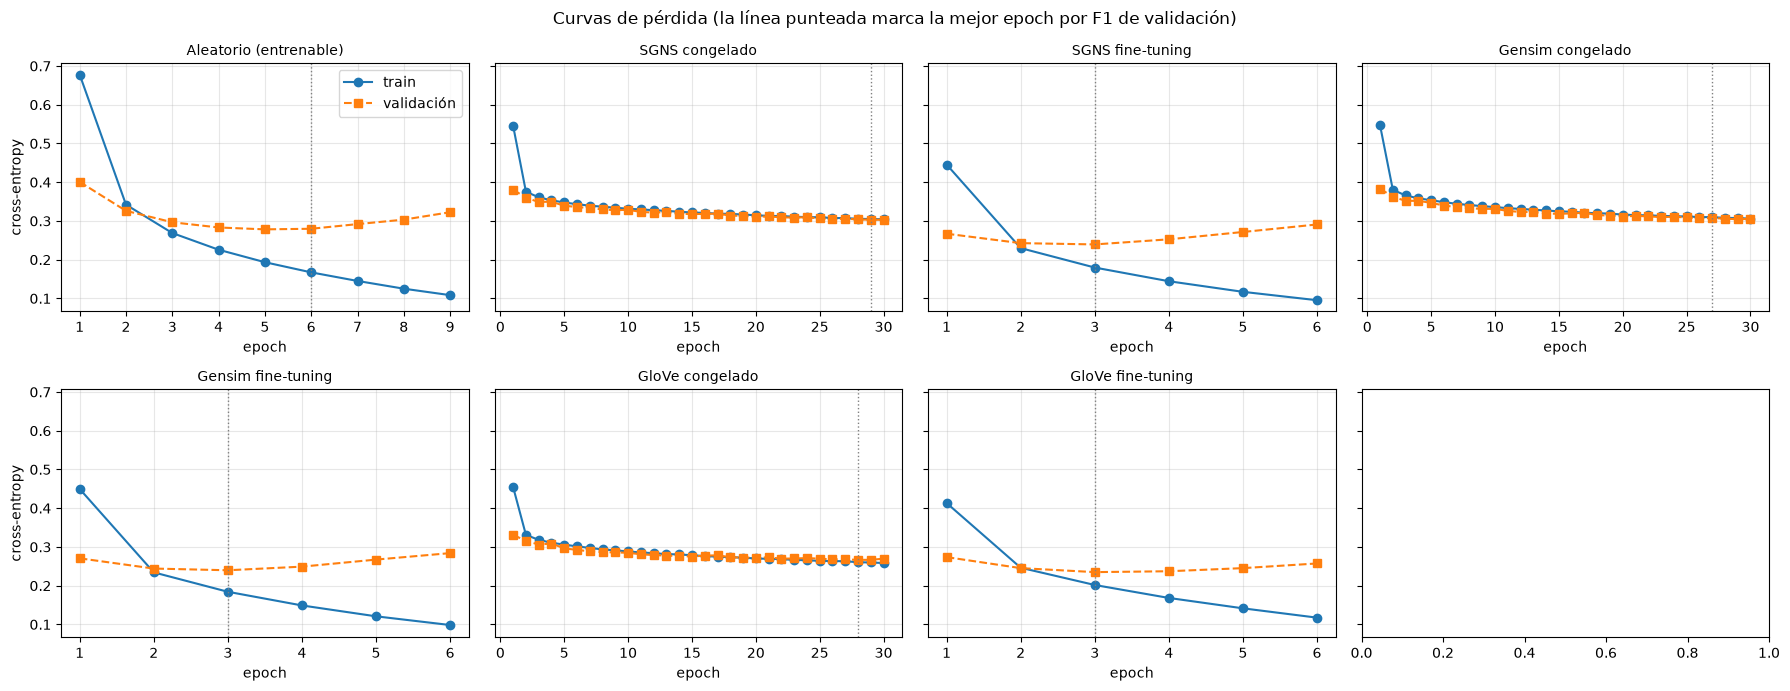

TF-IDF + LR (no iterativo): log-loss train 0.0628 | val 0.2390


In [34]:
nn_labels = [l for l, r in RES.items() if r["tipo"] == "nn"]
fig, axes = plt.subplots(2, math.ceil(len(nn_labels) / 2), figsize=(18, 7), sharey=True)
for ax, label in zip(axes.ravel(), nn_labels):
    ep = RES[label]["hist"]["epochs"]
    ax.plot([e["epoch"] for e in ep], [e["train_loss"] for e in ep], "o-", label="train")
    ax.plot([e["epoch"] for e in ep], [e["val_loss"] for e in ep], "s--", label="validación")
    ax.axvline(RES[label]["hist"]["mejor_epoch"], color="gray", ls=":", lw=1)
    ax.set_title(label, fontsize=10); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
axes.ravel()[0].legend(); axes[0, 0].set_ylabel("cross-entropy"); axes[1, 0].set_ylabel("cross-entropy")
plt.suptitle("Curvas de pérdida (la línea punteada marca la mejor epoch por F1 de validación)")
plt.tight_layout(); plt.show()

h = RES["TF-IDF + LR"]["hist"]
print(f"TF-IDF + LR (no iterativo): log-loss train {h['train_logloss']:.4f} | val {h['val_logloss']:.4f}")

### Evaluación final sobre test (una sola vez por inicialización)

Para cada tipo de inicialización se elige la mejor variante (congelada vs. fine-tuning) por F1 macro de validación y solo esa se evalúa en test.

,inicialización,mejor variante (val),accuracy,precision,recall,f1
0,TF-IDF,TF-IDF + LR,0.9200,0.9198,0.9200,0.9198
1,Aleatorio,Aleatorio (entrenable),0.9063,0.9066,0.9063,0.9063
2,SGNS,SGNS fine-tuning,0.9183,0.9182,0.9183,0.9181
3,Gensim,Gensim fine-tuning,0.9178,0.9177,0.9178,0.9176
4,GloVe,GloVe fine-tuning,0.9175,0.9175,0.9175,0.9174


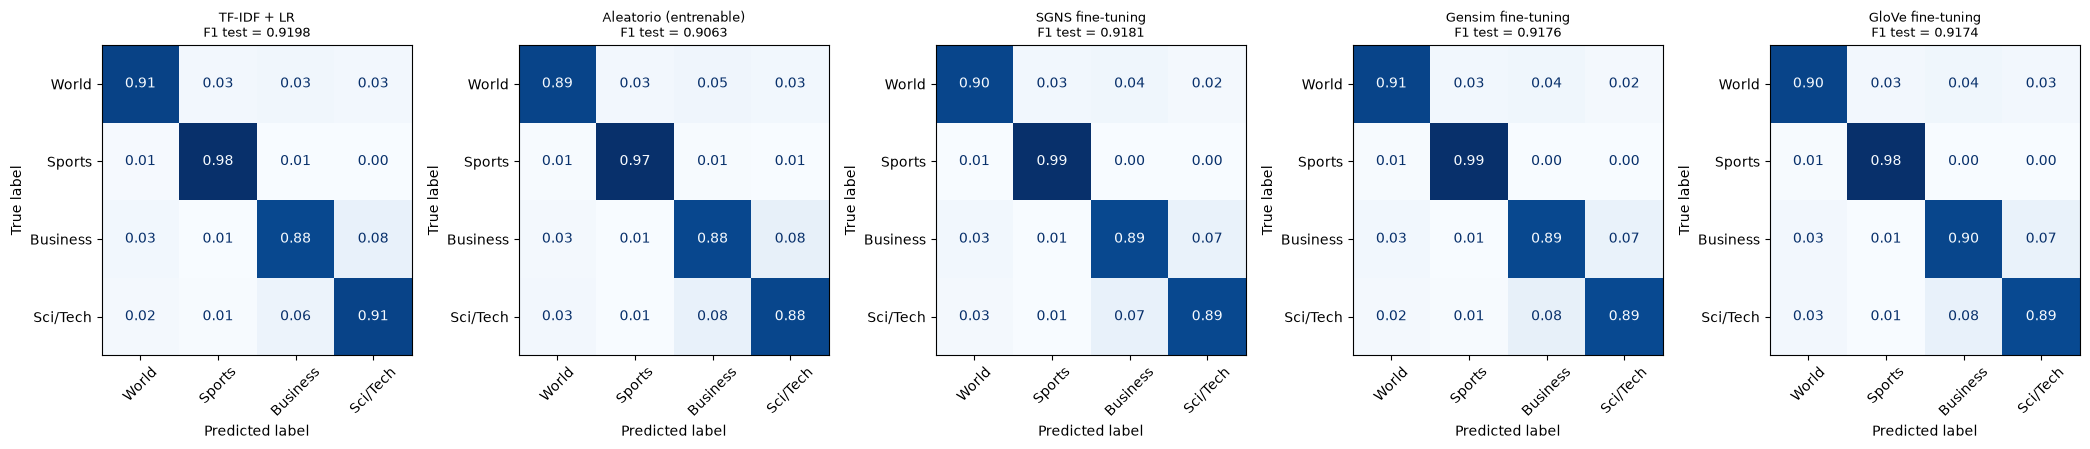

In [35]:
INIT_GROUPS = {
    "TF-IDF": ["TF-IDF + LR"],
    "Aleatorio": ["Aleatorio (entrenable)"],
    "SGNS": ["SGNS congelado", "SGNS fine-tuning"],
    "Gensim": ["Gensim congelado", "Gensim fine-tuning"],
    "GloVe": ["GloVe congelado", "GloVe fine-tuning"],
}
BEST_VARIANT, F1_TEST, test_rows, PRED_TEST = {}, {}, [], {}
for grp, labels in INIT_GROUPS.items():
    best = max(labels, key=lambda l: RES[l]["hist"]["val"]["f1"])
    BEST_VARIANT[grp] = best
    p = predict_test(RES[best])
    PRED_TEST[grp] = p
    m = clf_metrics(y_test, p)
    F1_TEST[grp] = m["f1"]
    test_rows.append({"inicialización": grp, "mejor variante (val)": best, **m})
tabla_test = pd.DataFrame(test_rows)
display(tabla_test.round(4))

fig, axes = plt.subplots(1, len(INIT_GROUPS), figsize=(4.2 * len(INIT_GROUPS), 4.2))
for ax, (grp, p) in zip(axes, PRED_TEST.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p, normalize="true"), display_labels=AG_CLASSES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{BEST_VARIANT[grp]}\nF1 test = {F1_TEST[grp]:.4f}", fontsize=9)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [ ]:
# SimLex-999 (evaluación final de los embeddings; no se usó para seleccionar) 
SIMLEX = {}
for key, kv in EMBEDDINGS.items():
    rho, oov = spearman_pairs(kv, simlex)
    SIMLEX[key] = rho
    print(f"{EMB_LABEL[key]:<28} SimLex-999 ρ = {rho:.4f}  (pares OOV: {oov:.1f} %)")

SGNS propio (t1e-4)          SimLex-999 ρ = 0.3016  (pares OOV: 0.1 %)
Word2Vec gensim              SimLex-999 ρ = 0.3147  (pares OOV: 0.1 %)
GloVe-100 (preentrenado)     SimLex-999 ρ = 0.2961  (pares OOV: 0.1 %)


# Inciso 7. Comparación de resultados

Tabla comparativa entre SGNS propio, Word2Vec de gensim y GloVe. Las columnas de analogías con 3CosAdd/3CosMul sobre el vocabulario compartido y la de paralelismo vienen del inciso 5 (`ANALOGIAS_52`, `PARALELISMO`). Si esas variables aún no existen, el 3CosAdd se toma del protocolo del inciso 4 (`evaluate_word_analogies` restringido a las 30,000 palabras más frecuentes de cada modelo; la columna "protocolo analogías" indica cuál se usó) y 3CosMul queda vacío.

In [37]:
ANALOGIAS_52 = globals().get("ANALOGIAS_52", {})          # lo llena la sección 5.2 (compañero)
PARALELISMO = globals().get("PARALELISMO", {})            # lo llena la sección 5.3 (compañero)
_FALLBACK = {"SGNS": HIST[BEST_NAME]["epochs"][-1],
             "Gensim": HIST_GENSIM[BEST_CFG["frac"]]["epochs"][-1],
             "GloVe": GLOVE_EVAL}

def analog_value(k, method, field):
    try:
        return float(ANALOGIAS_52[k][method][field])
    except (KeyError, TypeError):
        return float(_FALLBACK[k][field]) if method == "add" else np.nan

GLOVE_HW = ("Reportado por Pennington et al. (2014): construir la matriz de co-ocurrencia de 6B tokens ≈ 85 min "
            "(1 hilo, Xeon E5-2658 2.1 GHz); ≈ 14 min por iteración con d=300 usando 32 núcleos; "
            "50 iteraciones para d < 300")
_hs, _hg = HIST[BEST_NAME], HIST_GENSIM[BEST_CFG["frac"]]
META = {
    "SGNS": {"tokens": _hs["tokens_corpus"], "tiempo": f"{_hs['tiempo_entrenamiento_s']/60:.1f} min "
             f"({BEST_CFG['epochs']} epochs; GPU pico {_hs['gpu_pico_mb']:.0f} MB)", "hw": _hs["hardware"]},
    "Gensim": {"tokens": _hg["tokens_corpus"], "tiempo": f"{_hg['tiempo_entrenamiento_s']/60:.1f} min "
               f"({BEST_CFG['epochs']} epochs, {GENSIM_WORKERS} workers)", "hw": _hg["hardware"]},
    "GloVe": {"tokens": 6_000_000_000, "tiempo": "ver hardware", "hw": GLOVE_HW},
}

comp = []
for k, kv in EMBEDDINGS.items():
    comp.append({"modelo": EMB_LABEL[k], "tokens corpus": META[k]["tokens"], "|V|": len(kv), "dim": kv.vector_size,
                 "tiempo entrenamiento": META[k]["tiempo"], "hardware": META[k]["hw"],
                 "protocolo analogías": "vocab. compartido (5.2)" if k in ANALOGIAS_52 else "top-30k propio (inciso 4)",
                 "3CosAdd sem": analog_value(k, "add", "sem"), "3CosAdd sin": analog_value(k, "add", "syn"),
                 "3CosAdd total": analog_value(k, "add", "total"),
                 "3CosMul sem": analog_value(k, "mul", "sem"), "3CosMul sin": analog_value(k, "mul", "syn"),
                 "3CosMul total": analog_value(k, "mul", "total"),
                 "WS353 ρ": spearman_pairs(kv, wordsim)[0], "SimLex-999 ρ": SIMLEX[k],
                 "cos prom. vectores diferencia (5.3)": PARALELISMO.get(k, np.nan),
                 "% tokens OOV AG News": OOV_AG[k], "F1 test AG News": F1_TEST[k],
                 "variante AG News": BEST_VARIANT[k]})
tabla_comp = pd.DataFrame(comp).set_index("modelo")
save_json(tabla_comp.reset_index().to_dict(orient="records"), os.path.join(MODELS_DIR, "tabla_comparativa.json"))
pd.set_option("display.max_colwidth", 120)
tabla_comp.T

modelo,SGNS propio (t1e-4),Word2Vec gensim,GloVe-100 (preentrenado)
tokens corpus,83753871,83753871,6000000000
|V|,195026,195026,400000
dim,100,100,100
tiempo entrenamiento,11.0 min (3 epochs; GPU pico 2006 MB),"4.1 min (3 epochs, 23 workers)",ver hardware
hardware,NVIDIA GeForce RTX 4060 Laptop GPU,"Intel64 Family 6 Model 191 Stepping 2, GenuineIntel (24 hilos)","Reportado por Pennington et al. (2014): construir la matriz de co-ocurrencia de 6B tokens ≈ 85 min (1 hilo, Xeon E5-..."
protocolo analogías,top-30k propio (inciso 4),top-30k propio (inciso 4),top-30k propio (inciso 4)
3CosAdd sem,0.363218,0.347126,0.655448
3CosAdd sin,0.568988,0.5192,0.654535
3CosAdd total,0.502794,0.463846,0.654904
3CosMul sem,NaN,NaN,NaN


### Gráfica 1 — Accuracy de analogías vs. tokens del corpus

Accuracy total (3CosAdd, protocolo del inciso 4: `evaluate_word_analogies` restringido a las 30,000 palabras más frecuentes de cada modelo) en la última epoch. Hay tres curvas de tamaño de corpus (25 %, 50 % y 100 %): SGNS con la configuración base, SGNS con la mejor configuración y gensim con esa misma mejor configuración (comparación directa entre implementaciones). Los puntos grises son las demás iteraciones (100 % del corpus). GloVe (6 mil millones de tokens) es la línea de referencia.

=== SGNS t1e-4_c25: {'dim': 100, 'window': 5, 'neg': 5, 't': 0.0001, 'min_count': 5, 'lr': 0.002, 'epochs': 3, 'frac': 0.25, 'batch': 4096, 'name': 't1e-4_c25'} | tokens 20,938,562 | |V| 90,527
[t1e-4_c25] epoch 1/3 | loss 2.3537 | pares 71,887,905 | 47s | GPU pico 2190 MB
    | analogías sem 0.123 sin 0.213 total 0.185 | WS353 ρ 0.567
    vecinos: {'king': ['vikramaditya', 'æthelred', 'domnall', 'diarmait', 'æthelstan'], 'france': ['spain', 'italy', 'austria', 'belgium', 'netherlands'], 'computer': ['porting', 'computers', 'point-and-click', 'analog', 'hardware'], 'good': ['bad', 'pretty', 'flattered', 'darn', 'obviously'], 'january': ['february', 'march', 'december', 'april', 'november'], 'run': ['three-run', 'walk-off', 'eight-yard', 'game-tying', '13-yard']}
[t1e-4_c25] epoch 2/3 | loss 2.2221 | pares 71,889,068 | 49s | GPU pico 2191 MB
    | analogías sem 0.175 sin 0.316 total 0.273 | WS353 ρ 0.608
    vecinos: {'king': ['æthelred', '1189', 'vikramaditya', 'kamehameha', 'eadberht'

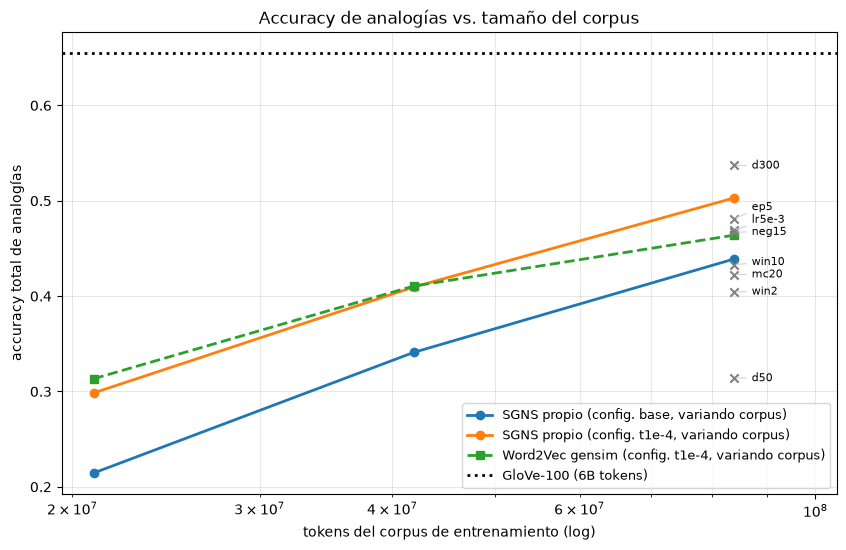

,modelo,tokens,analog. total,WS353 ρ
0,SGNS base,83753871,0.4388,0.6719
1,SGNS corpus25,20938562,0.2144,0.6067
2,SGNS corpus50,41877000,0.3409,0.6565
3,SGNS t1e-4,83753871,0.5028,0.6811
4,SGNS t1e-4_c25,20938562,0.2984,0.6169
5,SGNS t1e-4_c50,41877000,0.4095,0.6549
6,gensim t1e-4,20938562,0.3133,0.6359
7,gensim t1e-4,41877000,0.4105,0.6714
8,gensim t1e-4,83753871,0.4638,0.6736


In [38]:
# SGNS con la MEJOR configuración también en 25 % y 50 % del corpus, para compararlo directamente con gensim
# (misma config. en los tres tamaños). Se guardan en caché como los demás modelos.
EXTRA_CORPUS = {}
if BEST_NAME != "base":
    for f in (0.25, 0.5):
        cfg = dict(BEST_CFG, frac=f, name=f"{BEST_NAME}_c{int(f * 100)}")
        EXTRA_CORPUS[cfg["name"]] = train_sgns(cfg)

def corpus_series(ref):
    """Puntos (tokens, accuracy) de las iteraciones SGNS que solo difieren de `ref` en la fracción del corpus."""
    hs = [h for h in list(HIST.values()) + list(EXTRA_CORPUS.values())
          if all(h["config"][k] == ref[k] for k in BASE if k != "frac")]
    return sorted({h["tokens_corpus"]: h["epochs"][-1]["total"] for h in hs}.items())

fig, ax = plt.subplots(figsize=(10, 6))
lines = {"base": BASE} if BEST_NAME == "base" else {"base": BASE, BEST_NAME: BEST_CFG}
in_lines = set()
for nm, ref in lines.items():
    s = corpus_series(ref)
    ax.plot(*zip(*s), "o-", lw=2, label=f"SGNS propio (config. {nm}, variando corpus)")
    in_lines |= {n for n, h in HIST.items() if all(h["config"][k] == ref[k] for k in BASE if k != "frac")}
serie_g = sorted([(h["tokens_corpus"], h["epochs"][-1]["total"]) for h in HIST_GENSIM.values()])
ax.plot(*zip(*serie_g), "s--", lw=2, label=f"Word2Vec gensim (config. {BEST_NAME}, variando corpus)")

# demás iteraciones (100 % del corpus): puntos grises con etiquetas separadas para que no se encimen
otros = sorted([(h["epochs"][-1]["total"], n, h["tokens_corpus"]) for n, h in HIST.items() if n not in in_lines])
last_y = -1
for y, n, x in otros:
    ax.scatter(x, y, marker="x", color="gray", zorder=3)
    ly = max(y, last_y + 0.013)
    ax.annotate(n, (x, y), xytext=(x * 1.04, ly), textcoords="data", fontsize=8, va="center",
                arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.8))
    last_y = ly
ax.axhline(GLOVE_EVAL["total"], color="k", ls=":", lw=2, label="GloVe-100 (6B tokens)")
ax.set_xscale("log"); ax.set_xlim(right=max(h["tokens_corpus"] for h in HIST.values()) * 1.25)
ax.set_xlabel("tokens del corpus de entrenamiento (log)")
ax.set_ylabel("accuracy total de analogías"); ax.set_title("Accuracy de analogías vs. tamaño del corpus")
ax.grid(alpha=.3, which="both"); ax.legend(loc="lower right", fontsize=9)
plt.show()

pd.DataFrame([{"modelo": f"SGNS {n}", "tokens": h["tokens_corpus"], "analog. total": h["epochs"][-1]["total"],
               "WS353 ρ": h["epochs"][-1]["ws353"]}
              for n, h in list(HIST.items()) + list(EXTRA_CORPUS.items()) if n in in_lines or n in EXTRA_CORPUS]
             + [{"modelo": f"gensim {BEST_NAME}", "tokens": h["tokens_corpus"], "analog. total": h["epochs"][-1]["total"],
                 "WS353 ρ": h["epochs"][-1]["ws353"]} for h in HIST_GENSIM.values()]
             ).sort_values(["modelo", "tokens"]).round(4)

### Gráfica 2 — F1 de test vs. fracción de datos de entrenamiento de AG News

Se reentrena cada tipo de inicialización con 1 %, 5 %, 10 %, 25 %, 50 % y 100 % del train (submuestras estratificadas; misma validación para early stopping). Con pocos datos se permiten más epochs (`epochs_for`) y el vocabulario del clasificador usa frecuencia mínima 1. Los modelos al 100 % se reutilizan de la sección 6. Esta curva es un análisis: no se usa para elegir modelos.

frac 0.01  TF-IDF + LR              F1 test 0.8144 (1s)
frac 0.01  Aleatorio (entrenable)   F1 test 0.7192 (2s)
frac 0.01  SGNS congelado           F1 test 0.8491 (3s)
frac 0.01  SGNS fine-tuning         F1 test 0.8549 (1s)
frac 0.01  Gensim congelado         F1 test 0.8445 (3s)
frac 0.01  Gensim fine-tuning       F1 test 0.8221 (1s)
frac 0.01  GloVe congelado          F1 test 0.8576 (3s)
frac 0.01  GloVe fine-tuning        F1 test 0.8472 (1s)
frac 0.05  TF-IDF + LR              F1 test 0.8727 (3s)
frac 0.05  Aleatorio (entrenable)   F1 test 0.7783 (3s)
frac 0.05  SGNS congelado           F1 test 0.8666 (3s)
frac 0.05  SGNS fine-tuning         F1 test 0.8872 (2s)
frac 0.05  Gensim congelado         F1 test 0.8691 (4s)
frac 0.05  Gensim fine-tuning       F1 test 0.8761 (2s)
frac 0.05  GloVe congelado          F1 test 0.8797 (3s)
frac 0.05  GloVe fine-tuning        F1 test 0.8826 (2s)
frac 0.1   TF-IDF + LR              F1 test 0.8874 (4s)
frac 0.1   Aleatorio (entrenable)   F1 test 0.84

frac,0.01,0.05,0.10,0.25,0.50,1.00
modelo,,,,,,
TF-IDF + LR,0.8144,0.8727,0.8874,0.9032,0.9089,0.9198
Aleatorio (entrenable),0.7192,0.7783,0.8427,0.8787,0.8894,0.9063
SGNS congelado,0.8491,0.8666,0.8782,0.8804,0.8841,0.8899
SGNS fine-tuning,0.8549,0.8872,0.8925,0.9060,0.9104,0.9181
Gensim congelado,0.8445,0.8691,0.8742,0.8802,0.8830,0.8892
Gensim fine-tuning,0.8221,0.8761,0.8929,0.9051,0.9102,0.9176
GloVe congelado,0.8576,0.8797,0.8853,0.8896,0.8965,0.9025
GloVe fine-tuning,0.8472,0.8826,0.8960,0.9048,0.9115,0.9174


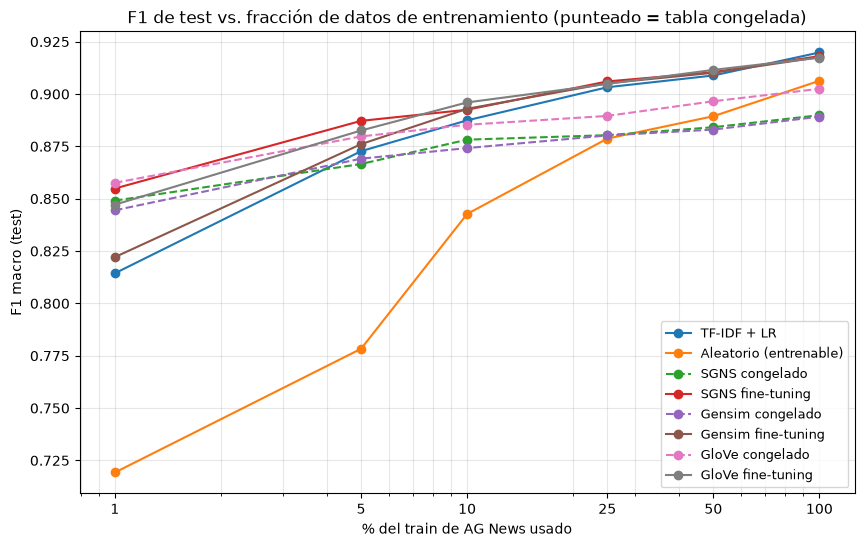

In [39]:
AG_FRACS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]

def sub_idx(frac):
    if frac >= 1:
        return idx_tr
    return train_test_split(idx_tr, train_size=frac, stratify=y_all[idx_tr], random_state=SEED)[0]

curve_path = os.path.join(MODELS_DIR, f"curva_ag_{BEST_NAME}.json")
curve = load_json(curve_path) if (os.path.exists(curve_path) and not FORCE_RETRAIN) else []
done = {(r["modelo"], r["frac"]) for r in curve}
for frac in AG_FRACS:
    tr_i = sub_idx(frac)
    for label, slug, kv, freeze in KINDS:
        if (label, frac) in done:
            continue
        t0 = time.time()
        r = run_kind(label, slug, kv, freeze, frac, tr_i, verbose=False)
        m = clf_metrics(y_test, predict_test(r))
        curve.append({"modelo": label, "frac": frac, "n_train": len(tr_i), "f1_test": m["f1"],
                      "acc_test": m["accuracy"], "f1_val": r["hist"]["val"]["f1"]})
        save_json(curve, curve_path)                     # guardar progreso tras cada modelo
        print(f"frac {frac:<5} {label:<24} F1 test {m['f1']:.4f} ({time.time()-t0:.0f}s)")
        del r
        gc.collect()

curve_df = pd.DataFrame(curve)
display(curve_df.pivot(index="modelo", columns="frac", values="f1_test").loc[[k[0] for k in KINDS]].round(4))

fig, ax = plt.subplots(figsize=(10, 6))
for label, slug, kv, freeze in KINDS:
    d = curve_df[curve_df["modelo"] == label].sort_values("frac")
    ls = "-" if freeze is not True else "--"
    ax.plot(d["frac"] * 100, d["f1_test"], "o" + ls, label=label)
ax.set_xscale("log"); ax.set_xticks([1, 5, 10, 25, 50, 100]); ax.set_xticklabels(["1", "5", "10", "25", "50", "100"])
ax.set_xlabel("% del train de AG News usado"); ax.set_ylabel("F1 macro (test)")
ax.set_title("F1 de test vs. fracción de datos de entrenamiento (punteado = tabla congelada)")
ax.grid(alpha=.3, which="both"); ax.legend(fontsize=9)
plt.show()